# Loading and processing electrophysiology data

## 1. Load data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py
from scipy.signal import savgol_filter
from scipy.io import loadmat
import sys
from scipy.linalg import hankel

from utilities.helper import filter_by_timestamp_range
import statsmodels.api as sm

filename = "rce_pilot_2_05_lfp_spectral_sleap_spikes.pkl"
# filename = "rce_pilot_2_10_per_trial_spectral_sleap_spikes.pkl"

TRIAL_LABELS_DF = pd.read_excel("rce2_finalized_trial_labels.xlsx")
LFP_SPECTRAL_DF = pd.read_pickle(filename)
# TRIALS_AND_SPECTRAL_DF = pd.merge(TRIAL_LABELS_DF, LFP_SPECTRAL_DF, on=["current_subject", "video_name"], how="inner", suffixes=('', '_y'))
LFP_SPECTRAL_DF.head()

,cohort,session_dir,tone_frames,box_1_port_entry_frames,box_2_port_entry_frames,video_name,session_path,recording,current_subject,subject,...,agent_locations,subject_thorax_velocity,agent_thorax_velocity,subject_thorax_to_reward_port,agent_thorax_to_reward_port,recording_name,spike_clusters,spike_times,neuron_average_fr,neuron_average_timestamps
0,2,20230617_115521_standard_comp_to_omission_D1_s...,"[[1029, 1229], [3425, 3624], [5721, 5920], [75...","[[102, 105], [110, 148], [193, 199], [200, 202...","[[24984, 31321], [39533, 39547], [39554, 39559...",20230617_115521_standard_comp_to_omission_D1_s...,/scratch/back_up/reward_competition_extention/...,20230617_115521_standard_comp_to_omission_D1_s...,1.1,1.1,...,NaN,"[14.84, 13.97, 13.13, 12.32, 11.54, 10.78, 10....",NaN,"[25.6, 25.84, 25.86, 25.86, 25.86, 25.86, 25.8...",NaN,20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0, 2000, 4000, 6000, 8000, 10000, 12000, 1400..."
1,2,20230617_115521_standard_comp_to_omission_D1_s...,"[[1029, 1229], [3425, 3624], [5721, 5920], [75...","[[102, 105], [110, 148], [193, 199], [200, 202...","[[24984, 31321], [39533, 39547], [39554, 39559...",20230617_115521_standard_comp_to_omission_D1_s...,/scratch/back_up/reward_competition_extention/...,20230617_115521_standard_comp_to_omission_D1_s...,1.1,1.1,...,"[[[40.039741738777444, 9.47029992556593], [42....","[8.96, 8.195, 7.54, 7.004, 6.605, 6.348, 6.227...","[11.19, 10.55, 9.92, 9.31, 8.734, 8.18, 7.64, ...","[11.19, 11.234, 11.73, 12.34, 12.56, 13.58, 13...","[25.6, 25.84, 25.86, 25.86, 25.86, 25.86, 25.8...",20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0, 2000, 4000, 6000, 8000, 10000, 12000, 1400..."
2,2,20230617_115521_standard_comp_to_omission_D1_s...,"[[1029, 1229], [3425, 3624], [5721, 5920], [75...","[[102, 105], [110, 148], [193, 199], [200, 202...","[[24984, 31321], [39533, 39547], [39554, 39559...",20230617_115521_standard_comp_to_omission_D1_s...,/scratch/back_up/reward_competition_extention/...,20230617_115521_standard_comp_to_omission_D1_s...,1.2,1.2,...,"[[[57.86163468579171, 31.554562356382696], [59...","[11.19, 10.55, 9.92, 9.31, 8.734, 8.18, 7.64, ...","[8.96, 8.195, 7.54, 7.004, 6.605, 6.348, 6.227...","[25.6, 25.84, 25.86, 25.86, 25.86, 25.86, 25.8...","[11.19, 11.234, 11.73, 12.34, 12.56, 13.58, 13...",20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...","[[1.0, 0.0, 1.0, 2.0, 1.0, 1.0, 0.0, 0.0, 0.0,...","[0, 2000, 4000, 6000, 8000, 10000, 12000, 1400..."
3,2,20230617_115521_standard_comp_to_omission_D1_s...,"[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[[0, 0], [0, 0], [0, 0], [0, 5], [12, 13], [13...",20230617_115521_standard_comp_to_omission_D1_s...,/scratch/back_up/reward_competition_extention/...,20230617_115521_standard_comp_to_omission_D1_s...,1.2,1.2,...,NaN,"[5.184, 4.777, 4.383, 4.0, 3.629, 3.271, 2.926...",NaN,"[6.223, 6.227, 6.234, 6.24, 6.203, 6.2, 6.203,...",NaN,20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...","[[1.0, 0.0, 1.0, 2.0, 1.0, 1.0, 0.0, 0.0, 0.0,...","[0, 2000, 4000, 6000, 8000, 10000, 12000, 1400..."
4,2,20230618_100636_standard_comp_to_omission_D2_s...,"[[1098, 1297], [3492, 3693], [5788, 5988], [75...","[[788, 835], [838, 839], [839, 871], [871, 900...","[[33026, 33037], [33038, 33042], [33044, 33049...",20230618_100636_standard_comp_to_omission_D2_s...,/scratch/back_up/reward_competition_extention/...,20230618_100636_standard_comp_to_omission_D2_s...,1.1,1.1,...,"[[[31.3

In [2]:
TRIAL_LABELS_DF.head()

,tracked_subject,box_number,sleap_name,video_name,current_subject,tone_start_frame,reward_start_frame,tone_stop_frame,condition,competition_closeness,notes,experiment,session_dir,all_subjects,tone_start_timestamp,tone_stop_timestamp,trial_label
0,1.1_1.2,1,20230612_112630_standard_comp_to_training_D1_s...,20230612_112630_standard_comp_to_training_D1_s...,1.1,1125,1225,1324,1.1,Subj 1 blocking Subj 2,NaN,standard,20230612_112630_standard_comp_to_training_D1_s...,"['1.1', '1.2']",1126742,1326741,win
1,1.1_1.2,1,20230612_112630_standard_comp_to_training_D1_s...,20230612_112630_standard_comp_to_training_D1_s...,1.2,1125,1225,1324,1.1,Subj 1 blocking Subj 2,NaN,standard,20230612_112630_standard_comp_to_training_D1_s...,"['1.1', '1.2']",1126742,1326741,lose
2,1.1_1.2,1,20230612_112630_standard_comp_to_training_D1_s...,20230612_112630_standard_comp_to_training_D1_s...,1.1,3519,3619,3720,1.2,Subj 2 Only,NaN,standard,20230612_112630_standard_comp_to_training_D1_s...,"['1.1', '1.2']",3526740,3726740,lose
3,1.1_1.2,1,20230612_112630_standard_comp_to_training_D1_s...,20230612_112630_standard_comp_to_training_D1_s...,1.2,3519,3619,3720,1.2,Subj 2 Only,NaN,standard,20230612_112630_standard_comp_to_training_D1_s...,"['1.1', '1.2']",3526740,3726740,win
4,1.1_1.2,1,20230612_112630_standard_comp_to_training_D1_s...,20230612_112630_standard_comp_to_training_D1_s...,1.1,5815,5915,6014,1.2,Subj 2 blocking Subj 1,NaN,standard,20230612_112630_standard_comp_to_training_D1_s...,"['1.1', '1.2']",5826740,6026737,lose


## 2. Combine & merge {spectral dataframe} with {trial label dataframe}

In [3]:
## Merging labels & LFP spectral
LFP_SPECTRAL_DF["video_name"] = LFP_SPECTRAL_DF["video_name"].apply(lambda x: x.strip(".videoTimeStamps.cameraHWSync"))
LFP_SPECTRAL_DF["current_subject"] = LFP_SPECTRAL_DF["current_subject"].astype(str)
TRIAL_LABELS_DF["current_subject"] = TRIAL_LABELS_DF["current_subject"].astype(str)

TRIALS_AND_SPECTRAL_DF = pd.merge(TRIAL_LABELS_DF, LFP_SPECTRAL_DF, on=["current_subject", "video_name"], how="inner", suffixes=('', '_y'))
# TRIALS_AND_SPECTRAL_DF = TRIALS_AND_SPECTRAL_DF.drop(columns=[col for col in TRIALS_AND_SPECTRAL_DF.columns if "trace" in col], errors="ignore")
TRIALS_AND_SPECTRAL_DF = TRIALS_AND_SPECTRAL_DF.drop(columns=[col for col in TRIALS_AND_SPECTRAL_DF.columns if "_y" in col], errors="ignore")
TRIALS_AND_SPECTRAL_DF.head()
# print(f"Number of experimental cohorts: {len(LFP_SPECTRAL_DF)}")
print(f"Number of experimental cohorts: {len(TRIALS_AND_SPECTRAL_DF)}")
# TRIALS_AND_SPECTRAL_DF.to_csv("TRIALS_AND_SPECTRAL_data_10pertrial.csv")

## Using Leo's filter func of LFP power, rather than my own, as it makes it easier.
## See trial_analysis.ipynb
TRIALS_AND_SPECTRAL_DF["baseline_start_timestamp"] = TRIALS_AND_SPECTRAL_DF["tone_start_timestamp"] - 30 * 20000
TRIALS_AND_SPECTRAL_DF["baseline_stop_timestamp"] = TRIALS_AND_SPECTRAL_DF["tone_start_timestamp"] - 20 * 20000
power_columns = [col for col in TRIALS_AND_SPECTRAL_DF.columns if "power" in col and "timestamps" not in col and "calculation" not in col]
# print(power_columns)
for col in power_columns:
    brain_region = col.replace("all_windows", "_").strip("_")
    updated_item_col = "trial_{}".format(brain_region)
    updated_timestamp_col = "trial_power_timestamps".format(brain_region)
    TRIALS_AND_SPECTRAL_DF[updated_item_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["tone_start_timestamp"], stop=x["tone_stop_timestamp"], timestamps=x["power_timestamps"], items=x[col])[1], axis=1)
TRIALS_AND_SPECTRAL_DF[updated_timestamp_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["tone_start_timestamp"], stop=x["tone_stop_timestamp"], timestamps=x["power_timestamps"], items=x[col])[0], axis=1)
for col in power_columns:
    brain_region = col.replace("all_windows", "_").strip("_")
    updated_item_col = "baseline_{}".format(brain_region)
    updated_timestamp_col = "baseline_power_timestamps".format(brain_region)
    TRIALS_AND_SPECTRAL_DF[updated_item_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["baseline_start_timestamp"], stop=x["baseline_stop_timestamp"], timestamps=x["power_timestamps"], items=x[col])[1], axis=1)
TRIALS_AND_SPECTRAL_DF[updated_timestamp_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["baseline_start_timestamp"], stop=x["baseline_stop_timestamp"], timestamps=x["power_timestamps"], items=x[col])[0], axis=1)
TRIALS_AND_SPECTRAL_DF = TRIALS_AND_SPECTRAL_DF.drop(columns=power_columns + ["power_timestamps"], errors="ignore")

## filtering coherence
''' Temporarily turned off, due to Performance errors (causes DataFrame fragmentation. See 2024-04-23 notes, or slurm-4378.out
coherence_columns = [col for col in TRIALS_AND_SPECTRAL_DF.columns if "coherence" in col and "timestamps" not in col and "calculation" not in col]
for col in coherence_columns:
    brain_region = col.replace("all_windows", "_").strip("_")
    updated_item_col = "baseline_{}".format(brain_region)
    updated_timestamp_col = "baseline_coherence_timestamps".format(brain_region)
    TRIALS_AND_SPECTRAL_DF[updated_item_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["baseline_start_timestamp"], stop=x["baseline_stop_timestamp"], timestamps=x["coherence_timestamps"], items=x[col])[1], axis=1)
TRIALS_AND_SPECTRAL_DF[updated_timestamp_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["baseline_start_timestamp"], stop=x["baseline_stop_timestamp"], timestamps=x["coherence_timestamps"], items=x[col])[0], axis=1)
for col in coherence_columns:
    brain_region = col.replace("all_windows", "_").strip("_")
    updated_item_col = "trial_{}".format(brain_region)
    updated_timestamp_col = "trial_coherence_timestamps".format(brain_region)
    TRIALS_AND_SPECTRAL_DF[updated_item_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["tone_start_timestamp"], stop=x["tone_stop_timestamp"], timestamps=x["coherence_timestamps"], items=x[col])[1], axis=1)
TRIALS_AND_SPECTRAL_DF[updated_timestamp_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["tone_start_timestamp"], stop=x["tone_stop_timestamp"], timestamps=x["coherence_timestamps"], items=x[col])[0], axis=1)
TRIALS_AND_SPECTRAL_DF = TRIALS_AND_SPECTRAL_DF.drop(columns=coherence_columns + ["coherence_timestamps"], errors="ignore")
'''
# print(TRIALS_AND_SPECTRAL_DF["trial_power_timestamps"])
# TRIALS_AND_SPECTRAL_DF = TRIALS_AND_SPECTRAL_DF.drop(columns=power_columns + ["power_timestamps"], errors="ignore")

Number of experimental cohorts: 368


' Temporarily turned off, due to Performance errors (causes DataFrame fragmentation. See 2024-04-23 notes, or slurm-4378.out\ncoherence_columns = [col for col in TRIALS_AND_SPECTRAL_DF.columns if "coherence" in col and "timestamps" not in col and "calculation" not in col]\nfor col in coherence_columns:\n    brain_region = col.replace("all_windows", "_").strip("_")\n    updated_item_col = "baseline_{}".format(brain_region)\n    updated_timestamp_col = "baseline_coherence_timestamps".format(brain_region)\n    TRIALS_AND_SPECTRAL_DF[updated_item_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["baseline_start_timestamp"], stop=x["baseline_stop_timestamp"], timestamps=x["coherence_timestamps"], items=x[col])[1], axis=1)\nTRIALS_AND_SPECTRAL_DF[updated_timestamp_col] = TRIALS_AND_SPECTRAL_DF.apply(lambda x: filter_by_timestamp_range(start=x["baseline_start_timestamp"], stop=x["baseline_stop_timestamp"], timestamps=x["coherence_timestamps"], items=x[col])[0], a

## 3. Filter to only keep unique neural recordings @ unique trial times

In [4]:
## Subject info
metadata = "subject"

subj_list = TRIALS_AND_SPECTRAL_DF[metadata].unique()
print(f"Total trial recordings per subject mice \n {TRIALS_AND_SPECTRAL_DF[metadata].value_counts(sort=False)}")

## filter replicate trials: only unique spike clusters & tone starts
print(f"Prior number of experimental trials: \n {len(TRIALS_AND_SPECTRAL_DF)}")
col_filter = ["session_dir", "spike_clusters", "spike_times", "tone_start_timestamp","current_subject"]

# TRIALS_AND_SPECTRAL_DFtemp = TRIALS_AND_SPECTRAL_DF.drop_duplicates() # returns error: numpy as unhashable type
TRIALS_AND_SPECTRAL_DFtemp = TRIALS_AND_SPECTRAL_DF.loc[TRIALS_AND_SPECTRAL_DF.astype(str).drop_duplicates(subset = col_filter).index]
print(f"Unique number of experimental trials: by {col_filter} \n {len(TRIALS_AND_SPECTRAL_DFtemp)}")
TRIALS_AND_SPECTRAL_DF = TRIALS_AND_SPECTRAL_DFtemp
TRIALS_AND_SPECTRAL_DFtemp.loc[:,col_filter].head(20)

Total trial recordings per subject mice 
 subject
1.1    117
1.2     95
1.4    156
Name: count, dtype: int64
Prior number of experimental trials: 
 368
Unique number of experimental trials: by ['session_dir', 'spike_clusters', 'spike_times', 'tone_start_timestamp', 'current_subject'] 
 232


,session_dir,spike_clusters,spike_times,tone_start_timestamp,current_subject
0,20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...",1030879,1.1
2,20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...",1030879,1.2
3,20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...",3430878,1.1
5,20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...",3430878,1.2
6,20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...",5730880,1.1
8,20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...",5730880,1.2
9,20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...",7530877,1.1
11,20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...",7530877,1.2
12,20230617_115521_standard_comp_to_omission_D1_s...,"[3, 4, 5, 6, 17, 28, 29, 39, 48, 52, 53, 54, 5...","[[673223.0, 2367433.0, 2569212.0, 3969647.0, 3...",8630880,1.1
14,20230617_115521_standard_comp_to_omission_D1_s...,"[16, 17, 20, 25, 26, 34, 35, 39, 40, 42, 43, 4...","[[958.0, 5233.0, 6331.0, 7475.0, 8599.0, 10550...",8630880,1.2


## 4. Helper function: filter spikes by start/stop timeframe

In [5]:
def filter_spike_times(arr_2d, start, stop, padding=-1):
    """
    Filters a 2D array based on a start and stop condition and pads shorter arrays to match the length of the longest array.

    Parameters:
    arr_2d (numpy.ndarray): 2D array to be filtered and padded.
    start (int or float): Lower bound of the condition.
    stop (int or float): Upper bound of the condition.
    padding (int or float): Value to use for padding, defaults to -1.

    Returns:
    numpy.ndarray: A 2D array where each inner array has been filtered based on the condition and padded to match the length of the longest array.
    """

    # Filter each row in arr_2d based on the condition
    masked_data = [row[(row >= start) & (row < stop)] for row in arr_2d]

    # Determine the maximum length of arrays in the list
    max_length = max(len(arr) for arr in masked_data)

    # Pad each array in masked_data with the padding value so they all have the same length (max_length)
    padded_arrays = [np.concatenate([x, np.full([max_length - len(x)], padding)]) for x in masked_data]

    # Convert the list of arrays to a 2D numpy array
    padded_arrays = np.array(padded_arrays)

    return padded_arrays

## 5. Filter dataframe's \["spike_clusters"] and \["spike_times"] to only include neurons above a minimum firing rate
- and applying said filter

In [6]:
## dataframe_spike_minfreq_filter
def dataframe_spike_minfreq_filter(dataframe, min_freq = 5, condition = "TRIAL", show_plot=False, print_trial_info = True):
    '''
    WARNING: Does not work for min_freq = 0, as it attempts to replace with empty float values. TBF
    Takes electrophysiology dataframe and returns a copy where "spike_clusters" and "spike_times" only includes spikes above a certain frequency
    main parameters:
        - dataframe: pandas dataframe of file
        - min_freq: minimum frequency to filter [Hz]
        - condition: time period to check frequency over
            - "TRIAL": from "tone_start_timestamp" to 10*20000 frames (10 seconds) after. Returns different spike times per row
            - False: check entire duration. Returned "spike_clusters" and "spike_times" will still be over full duration
    '''
    avg_firing_list = []
    cutoff = []
    df_filtered = dataframe.copy(deep=True)
    spike_clusters_list = []
    spike_times_list = []
    
    for idx, trial in dataframe.iterrows():       
        spike_clusters = trial["spike_clusters"] # spike cluster identities (type: list)
        spike_times = trial["spike_times"]
        if (condition == "TRIAL"):
            trial_start_timestamp = trial["tone_start_timestamp"]
            trial_stop_timestamp = trial_start_timestamp + 10*20000
            # duration = trial_stop_timestamp - trial_start_timestamp
            duration = 10 # duration in seconds
            spike_times = filter_spike_times(spike_times, trial_start_timestamp, trial_stop_timestamp)
        else:
            trial_start_timestamp = trial["first_timestamp"]
            trial_stop_timestamp = trial["last_timestamp"]
            duration = (trial_stop_timestamp-trial_start_timestamp)/20000 # duration in seconds
        
        avg_firing = [(len(np.unique(spike_times[i]))-1)/(duration) for i in range(len(spike_clusters))]
        num_cells = len(spike_clusters)
        # print(f"{num_cells}/{len(avg_firing)}/{len(spike_times)}")
        # print(f"Neuron {spike_clusters} avg_firing {avg_firing}")
        # print(f"Number of neurons: {num_cells}")
        
        if min_freq:
            spike_times = spike_times[[avg_firing[i]>min_freq for i in range(spike_times.shape[0])],:]
            spike_clusters = [cell for i,cell in enumerate(spike_clusters) if avg_firing[i]>min_freq]
            avg_firing = [(len(np.unique(spike_times[i]))-1)/(duration) for i in range(len(spike_clusters))]
        # print(f"Filtered cell_num: {num_cells_new}")
            cutoff.append(round(len(spike_clusters)/num_cells, 4))

            # updating new spike_clusters and spike_times to only include filtered
            # df_filtered["spike_clusters"].loc[idx] = spike_clusters
            # df_filtered["spike_times"].loc[idx] = spike_times
            # df_filtered.iloc[idx, ["spike_clusters"]] = spike_clusters # error: attempts to take list of spike clusters at multiple rows
            # df_filtered.iloc[idx, ["spike_times"]] = spike_times
            spike_clusters_list.append(spike_clusters)
            spike_times_list.append(spike_times)
        avg_firing_list.append(avg_firing)

    if min_freq:
        df_filtered["spike_clusters"] = pd.Series(spike_clusters_list)
        df_filtered["spike_times"] = pd.Series(spike_times_list)
    if (condition != "TRIAL"): df_filtered["avg_firing"] = pd.Series(avg_firing_list) 
    # iterate over dataframe's rows, to find spike firing rates per session
    if show_plot:
        x_idx = (np.arange(len(avg_firing_list))+1)*10
        plt.figure()
        # plt.scatter(x_idx, avg_firing)
        for i, list in enumerate(avg_firing_list):
            plt.scatter(x_idx[i]*np.ones(len(list)), list)
    print(f"Fraction cutoff for {min_freq}Hz: {np.mean(np.array(cutoff))}")
    if print_trial_info:
        print(f"Number of trials: {len(avg_firing_list)}")
        for idx, avg in enumerate(avg_firing_list):
            print(['%.2f' % i for i in avg]) # rounded to hundredth
    return df_filtered


min_freq = 5
TRIALS_AND_SPECTRAL_DF_filt = dataframe_spike_minfreq_filter(TRIALS_AND_SPECTRAL_DF, condition = False, min_freq=min_freq, show_plot=False, print_trial_info = True)

Fraction cutoff for 5Hz: 0.18187887931034485
Number of trials: 232
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12']
['7.33', '21.18']
['8.24', '8.32', '13.70', '8.31', '7.00', '13.46', '10.12

## 6. Train-test split

In [7]:
## Train-test split
from sklearn.model_selection import train_test_split
## Data of original experiment

## Filter dataframe based on session. modify "metadata" based on desired condition. 
# metadata = "competition_closeness"
metadata = "session_dir"
# metadata = "trial_label"

print(TRIALS_AND_SPECTRAL_DF_filt[metadata].unique())
print(f"{TRIALS_AND_SPECTRAL_DF_filt[metadata].value_counts(sort=False)}")

## separate dataframe, of only data from first session_dir
meta_idx = 0 # replaces exp_idx
neuron_idx = 0 # replaces cell_idx

df_sess = TRIALS_AND_SPECTRAL_DF_filt.loc[(TRIALS_AND_SPECTRAL_DF_filt[metadata] == TRIALS_AND_SPECTRAL_DF_filt[metadata].unique()[meta_idx])]
df_sess_train, df_sess_test = train_test_split(df_sess, train_size=0.8, shuffle=True, random_state = 42) # random_state used to lock randomization

print(f"trial {TRIALS_AND_SPECTRAL_DF_filt[metadata].unique()[meta_idx]} num:{df_sess.shape[0]}, train size: {df_sess_train.shape[0]}, test size: {df_sess_test.shape[0]}")
col_filter = ["session_dir", "spike_clusters", "spike_times", "tone_start_timestamp","current_subject", "avg_firing"]
df_sess_train.loc[:,col_filter].head()

['20230617_115521_standard_comp_to_omission_D1_subj_1-1_and_1-2'
 '20230618_100636_standard_comp_to_omission_D2_subj_1-4_and_1-1'
 '20230620_114347_standard_comp_to_omission_D4_subj_1-2_and_1-1'
 '20230621_111240_standard_comp_to_omission_D5_subj_1-4_and_1-2']
session_dir
20230617_115521_standard_comp_to_omission_D1_subj_1-1_and_1-2    42
20230618_100636_standard_comp_to_omission_D2_subj_1-4_and_1-1    76
20230620_114347_standard_comp_to_omission_D4_subj_1-2_and_1-1    74
20230621_111240_standard_comp_to_omission_D5_subj_1-4_and_1-2    40
Name: count, dtype: int64
trial 20230617_115521_standard_comp_to_omission_D1_subj_1-1_and_1-2 num:42, train size: 33, test size: 9


,session_dir,spike_clusters,spike_times,tone_start_timestamp,current_subject,avg_firing
9,20230617_115521_standard_comp_to_omission_D1_s...,"[17, 20, 34, 35, 43, 47, 73]","[[123.0, 1869.0, 8550.0, 8669.0, 8784.0, 13214...",7530877,1.1,"[8.238038354131382, 8.318089963579654, 13.7028..."
41,20230617_115521_standard_comp_to_omission_D1_s...,"[17, 20, 34, 35, 43, 47, 73]","[[123.0, 1869.0, 8550.0, 8669.0, 8784.0, 13214...",21330874,1.2,"[8.238038354131382, 8.318089963579654, 13.7028..."
18,20230617_115521_standard_comp_to_omission_D1_s...,"[29, 59]","[[13535.0, 14381.0, 26228.0, 26490.0, 39841.0,...",11530876,1.1,"[7.334885556625629, 21.178042245041112]"
26,20230617_115521_standard_comp_to_omission_D1_s...,"[29, 59]","[[13535.0, 14381.0, 26228.0, 26490.0, 39841.0,...",15130878,1.2,"[7.334885556625629, 21.178042245041112]"
14,20230617_115521_standard_comp_to_omission_D1_s...,"[29, 59]","[[13535.0, 14381.0, 26228.0, 26490.0, 39841.0,...",8630880,1.2,"[7.334885556625629, 21.178042245041112]"


In [8]:
df_sess.loc[:,["spike_clusters", "trial_label","current_subject", "tone_start_timestamp"]].head(10)

,spike_clusters,trial_label,current_subject,tone_start_timestamp
0,"[29, 59]",lose,1.1,1030879
2,"[29, 59]",win,1.2,1030879
3,"[17, 20, 34, 35, 43, 47, 73]",win,1.1,3430878
5,"[17, 20, 34, 35, 43, 47, 73]",lose,1.2,3430878
6,"[29, 59]",win,1.1,5730880
8,"[29, 59]",lose,1.2,5730880
9,"[17, 20, 34, 35, 43, 47, 73]",lose,1.1,7530877
11,"[17, 20, 34, 35, 43, 47, 73]",win,1.2,7530877
12,"[29, 59]",win,1.1,8630880
14,"[29, 59]",lose,1.2,8630880


## 7. DesMat generator, and dataframe info extractor for spike times

- `ntfilt` = 50 # 25 150 # num time bins for stimulus' prediction
- `nthist` = 40 # 20 100 # number of auto-regressive spike-history time bins
- `spike_displ` = 75 # num of timeframes to display in spikes' plot
- `num_time_bins_spike` = 700  
- values saved in `trial_dict` (output of **dataframe_DesMat**)
    - "cell_idx": cell_idx,  
    - "ntfilt": ntfilt, *number of time bins for LFP prediction*: ~50  
    - "nthist": nthist, *number of auto-regressive spike-history time bins*: ~40  
    - "exp_id": exp_id,  
    - "duration": duration,  
    - "spike_times": spike_times,  
    - "lfp": lfp,  
    - "lfp_times":lfp_times,  
    - "dt_lfp": dt_lfp,  
    - "dt_spike": dt_spike,  
    - "num_time_bins": num_time_bins, *number of time points in LFP*
        - `num_time_bins_int == num_time_bins_spike`
    - "num_time_bins_spike": num_time_bins_spike, *number of time points in Spikes*
    - ~~"min_freq": min_freq,~~
    - "num_cells": num_cells,
    - "avg_firing": avg_firing,
    - "spikes_binned": spikes_binned,
    - "all_spikes_binned": all_spikes_binned,
    - "design_mat_spikes": design_mat_spikes,
    - "design_mat_spike_offset": design_mat_spike_offset,
    - "design_mat_all_spikes": design_mat_all_spikes,
    - "design_mat_allSpike_offset": design_mat_allSpike_offset

In [9]:
## Function for DesMat generation
def dataframe_DesMat(exp_id, cell_idx=0, dataframe = TRIALS_AND_SPECTRAL_DF,
                    min_freq = False, ntfilt = 50, nthist = 40, num_time_bins_spike = 3000,
                    print_trial_info = False, plot_xlim = [0, 200000], timefr_condition = "trial"
                    ):
    '''
    returns offset design matrix for single-spike-history & multi-spike-history, for input into model.
    exp_id: row of dataframe to extract
    cell_id: index of neuron spike of interest
    min_freq: only neuron spikes with frequencies above this value are kept. set as 0 to include all
    ntfilt: num time bins for stimulus' prediction
    nthist: number of auto-regressive spike-history time bins

    ## Returns:
    ---
    return_spikes: returns binned spikes instead (for plotting)
    print_trial_info: prints & shows plot of trial mLFP & spikes
    trial_dict: dictionary of experiment's parameters
        unpack with: `keys, values = trial_dict.keys(), trial_dict.values()`
    '''
    
    spike_clusters = dataframe["spike_clusters"].iloc[exp_id] # spike cluster identities (type: list)
    spike_times = dataframe["spike_times"].iloc[exp_id]
    lfp = dataframe["mPFC_lfp_trace"].iloc[exp_id]
    lfp_times = dataframe["lfp_timestamps"].iloc[exp_id]
    
    ### Set timeframe of interest
    ## "baseline -> trial" 30 seconds before trial tone to 20 seconds before trial tone
    # trial_start_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id] - 30*20000
    # trial_stop_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id] - 20*20000
    ###
    if (timefr_condition == "baseline"):
        trial_start_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id] - 30*20000
        trial_stop_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id] - 20*20000
    ## "trial" is from tone start to 10 seconds after onset
    # trial_start_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id]

    else:
        trial_start_timestamp = dataframe["tone_start_timestamp"].iloc[exp_id]
        trial_stop_timestamp = trial_start_timestamp + 10*20000
    
    ## "trial +/- 5" 5 seconds before trial tone start, to 15 seconds after
    # trial_start_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id] - 5*20000
    # trial_stop_timestamp = TRIAL_LABELS_DF["tone_start_timestamp"].iloc[exp_id] + 15*20000
    # not yet implemented

    spike_times = filter_spike_times(spike_times, trial_start_timestamp, trial_stop_timestamp)
    lfp_times, lfp = filter_by_timestamp_range(start=trial_start_timestamp, stop=trial_stop_timestamp, timestamps=lfp_times, items=lfp)
    
    duration = trial_stop_timestamp - trial_start_timestamp
    avg_firing = [(len(np.unique(spike_times[i]))-1)/(duration/20000) for i in range(len(spike_clusters))]
    num_cells = len(spike_clusters)
    
    dt_lfp = lfp_times[1]-lfp_times[0]
    num_time_bins = lfp.size
    
    # num_time_bins_spike = 700 # Redefined in function params. 200 100 ## adjust to keep spike and stim bin sizes separate
    dt_spike = duration/num_time_bins_spike
    
    ## filter frequency threshold
    if min_freq:
        spike_times = spike_times[[avg_firing[i]>min_freq for i in range(spike_times.shape[0])],:] # only keep rows whose average firing is above min_freq
        # spike_clusters = spike_clusters[avg_firing[i]>min_freq for i in spike_times.shape[0]]
        spike_clusters = [cell for i,cell in enumerate(spike_clusters) if avg_firing[i]>min_freq]
        num_cells = len(spike_clusters)
        avg_firing = [(len(np.unique(spike_times[i]))-1)/(duration/20000) for i in range(len(spike_clusters))]
    
    ## Binning Spike Trains
    spikes_bin_centers = np.arange(num_time_bins_spike+1)*dt_spike
    all_spikes_binned = np.zeros((num_time_bins_spike, num_cells))
    for idx in range(num_cells):
        # (1) removes padding of -1 (2) shifts timefr to start at 0
        temp = spike_times[idx][spike_times[idx] != -1]-trial_start_timestamp
        all_spikes_binned[:,idx] = np.histogram(temp,spikes_bin_centers)[0]

    # print(f"all spikes array: {all_spikes_binned.shape}")

    # if no neurons' spiking are above freq threshold, return zeros as spiking bins.
    spikes_binned = all_spikes_binned[:,cell_idx] if all_spikes_binned.shape[1] != 0 else np.zeros((num_time_bins_spike))
    total_spikes_binned = np.sum(all_spikes_binned, axis=1)
    # print(spikes_binned.shape)
    
    if print_trial_info:
        print(f"Data summary for experimental trial idx{exp_id}")
        print(f"timefr duration: {duration} at 20,000Hz = {duration/20000}s")
        print(f"timeframes btwn. LFP: {dt_lfp}")
        print(f"timeframes btwn. Spikes: {dt_spike}")
        print(f"num_time_bins (lfp) = {num_time_bins} of size {duration/num_time_bins} timeframes or {duration/20000/num_time_bins} seconds")
        print(f"num_time_bins_spike = {num_time_bins_spike} of size {duration/num_time_bins_spike} timeframes or {duration/20000/num_time_bins_spike:.3} seconds")
        if min_freq: print(f"freq. filter applied: only keeping cells above {min_freq}Hz") 
        print(f"number of cells: {num_cells}")
        print(f"spike_times shape: {spike_times.shape}, type: {type(spike_times)}")
        print(f"Spike index ({len(spike_clusters)}): {spike_clusters}")
        print(f"Total spikes over condition duration: {[(len(np.unique(spike_times[i]))-1) for i in range(len(spike_clusters))]}")
        print("Average firing rate per neuron")
        print(['%.2f' % i for i in avg_firing]) # rounded to hundredth
        
        iiplot = np.arange(len(lfp))
        ttplot = iiplot*dt_lfp
        ttplot_spike = np.arange(num_time_bins_spike)*dt_spike
        
        fig, ax = plt.subplots(len(spike_clusters)+2)
        fig.set_figheight(4.8*len(spike_clusters)) # defaults: width=6.4, height=4.8
        fig.set_figwidth(12.8)
        ax[0].plot(ttplot, lfp)
        # ax[0].stem(ttplot_spike,all_spikes_binned[:,cell_idx], '-r', markersize=15)
        ax[0].set_xlim(plot_xlim)
        ax[0].set_title(f"mPFC LFP trace of experiment {exp_id}")
        ax[0].set_xlabel("timeframe (20k Hz)")
        ax[1].plot(ttplot_spike, np.sum(all_spikes_binned, axis=1))
        ax[1].set_xlim(plot_xlim)
        ax[1].set_title(f"total spikes of experiment {exp_id}")
        for i in range(len(spike_clusters)):
            ax[i+2].stem(ttplot_spike,all_spikes_binned[:,i])
            ax[i+2].set_xlim(plot_xlim)
            ax[i+2].set_title(f"spikes of idx{i}/neuron#{spike_clusters[i]} (avg firing:{avg_firing[i]}Hz) (num_spikes:{(len(np.unique(spike_times[i]))-1)})")
        fig.tight_layout()
    
    padded_spikes = np.hstack((np.zeros(nthist), spikes_binned[:-1]))
    design_mat_spikes = hankel(padded_spikes[:-nthist+1], padded_spikes[-nthist:])
    design_mat_spike_offset = np.hstack((np.ones((num_time_bins_spike,1)), design_mat_spikes))

    design_mat_all_spikes = np.zeros((num_time_bins_spike, nthist, num_cells)) # allocate space
    # Loop over neurons to build design matrix, exactly as above
    for j in np.arange(num_cells):
        padded_spikes = np.hstack((np.zeros(nthist), all_spikes_binned[:-1,j]))
        design_mat_all_spikes[:,:,j] = hankel(padded_spikes[:-nthist+1], padded_spikes[-nthist:])
    # Reshape it to be a single matrix
    design_mat_all_spikes = np.reshape(design_mat_all_spikes, (num_time_bins_spike,-1), order='F')
    design_mat_allSpike_offset = np.hstack((np.ones((num_time_bins_spike,1)), design_mat_all_spikes))

    trial_dict = {
        "cell_idx": cell_idx,
        "ntfilt": ntfilt,
        "nthist": nthist,
        
        "exp_id": exp_id,
        "duration": duration,

        "spike_clusters": spike_clusters,
        "spike_times": spike_times,
        "lfp": lfp,
        "lfp_times":lfp_times,
        
        "dt_lfp": dt_lfp,
        "dt_spike": dt_spike,
        "num_time_bins": num_time_bins,
        "num_time_bins_spike": num_time_bins_spike,
        # "min_freq": min_freq,
        "num_cells": num_cells,
        "avg_firing": avg_firing,
        
        "spikes_binned": spikes_binned,
        "all_spikes_binned": all_spikes_binned,
        "total_spikes_binned": total_spikes_binned,

        "design_mat_spikes": design_mat_spikes,
        "design_mat_spike_offset": design_mat_spike_offset,
        "design_mat_all_spikes": design_mat_all_spikes,
        "design_mat_allSpike_offset": design_mat_allSpike_offset
    }

    
    
    ## unfinished: to return model and/or rate pred
    # pGLMsp_model = sm.GLM(endog=spikes_binned, exog=design_mat_spike_offset, family=sm.families.Poisson())
    # pGLMsp_results = pGLMsp_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    # pGLMsp_const = pGLMsp_results.params[0]
    # pGLMsp_filt = pGLMsp_results.params[1:] # spike history only filter
    # rate_pred_sp = np.exp(pGLMsp_const + design_mat_spikes @ pGLMsp_filt)

    # pGLM_allSpike_model = sm.GLM(endog=spikes_binned, exog=design_mat_allSpike_offset,
    #                          family=sm.families.Poisson())
    # pGLM_allSpike_results = pGLM_allSpike_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    
    # pGLM_allSpike_const = pGLM_allSpike_results.params[0]
    # pGLM_allSpike_filt = pGLM_allSpike_results.params[1:]
    # pGLM_allSpike_filt = np.reshape(pGLM_allSpike_filt, (nthist,num_cells), order='F')
    # rate_pred_all = np.exp(pGLM_allSpike_const + design_mat_all_spikes @ pGLM_allSpike_results.params[1:])
    
    return  trial_dict

def dataframe_DesMatPlot(exp_id, cell_idx, dataframe = TRIALS_AND_SPECTRAL_DF,
                         min_freq = 0, ntfilt = 50, nthist = 40, rate_plot=True,
                         inplot_xlim = [0, 200000], show_input = False, timefr_condition_plot = "trial"):
    ## intakes dataframe_DesMat data and generates plots
    trial_dict = dataframe_DesMat(exp_id, cell_idx, dataframe,
                                  min_freq, ntfilt, nthist, 
                                  plot_xlim = inplot_xlim, print_trial_info=show_input, timefr_condition=timefr_condition_plot)

    ## extract from dict
    design_mat_spikes = trial_dict["design_mat_spikes"]
    design_mat_all_spikes = trial_dict["design_mat_all_spikes"]
    design_mat_spike_offset = trial_dict["design_mat_spike_offset"]
    design_mat_allSpike_offset = trial_dict["design_mat_allSpike_offset"]
    spikes_binned = trial_dict["spikes_binned"]
    nthist = trial_dict["nthist"]
    num_cells = trial_dict["num_cells"]
    ttplot_spike = np.arange(trial_dict["num_time_bins_spike"])*trial_dict["dt_spike"]

    ## generate model & rate preds
    pGLMsp_model = sm.GLM(endog=spikes_binned, exog=design_mat_spike_offset, family=sm.families.Poisson())
    pGLMsp_results = pGLMsp_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    pGLMsp_const = pGLMsp_results.params[0]
    pGLMsp_filt = pGLMsp_results.params[1:] # spike history only filter
    rate_pred_sp = np.exp(pGLMsp_const + design_mat_spikes @ pGLMsp_filt)
    
    pGLM_allSpike_model = sm.GLM(endog=spikes_binned, exog=design_mat_allSpike_offset,
                             family=sm.families.Poisson())
    pGLM_allSpike_results = pGLM_allSpike_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    pGLM_allSpike_const = pGLM_allSpike_results.params[0]
    pGLM_allSpike_filt = pGLM_allSpike_results.params[1:] # pGLM_all_results.params[1:ntfilt+1]
    pGLM_allSpike_filt = np.reshape(pGLM_allSpike_filt, (nthist,num_cells), order='F')
    rate_pred_all = np.exp(pGLM_allSpike_const + design_mat_all_spikes @ pGLM_allSpike_results.params[1:])

    if rate_plot:
        plt.figure(figsize=[15,15/2])
        plt.stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', label="spike ct")
        plt.plot(ttplot_spike, rate_pred_sp, label="exp-poisson GLM sp", c='orange')
        plt.plot(ttplot_spike, rate_pred_all, label=f"exp-poisson GLM, all spikes", c='red')
        plt.xlim(inplot_xlim)
        plt.title(f"Rate pred/spike of cell{cell_idx} of ex{exp_id}")
        plt.ylabel('spike count / bin')
        plt.xlabel('timeframes')
        plt.legend(loc='upper right')
        plt.tight_layout()

## To test Function
# trial_dict = dataframe_DesMat(exp_id=11, cell_idx=5, min_freq = 7, print_trial_info = True)
# dataframe_DesMatPlot(exp_id=11, cell_idx=5, min_freq = 7)

# Predicting Spikes from its own history

Note: May need to modify Graphs to make it more presentable

## First: Using only a the data from a single trial (~10 seconds duration)

Data summary for experimental trial idx0
timefr duration: 200000 at 20,000Hz = 10.0s
timeframes btwn. LFP: 20
timeframes btwn. Spikes: 66.66666666666667
num_time_bins (lfp) = 10000 of size 20.0 timeframes or 0.001 seconds
num_time_bins_spike = 3000 of size 66.66666666666667 timeframes or 0.00333 seconds
number of cells: 7
spike_times shape: (7, 143), type: <class 'numpy.ndarray'>
Spike index (7): [17, 20, 34, 35, 43, 47, 73]
Total spikes over condition duration: [79, 74, 142, 124, 95, 127, 96]
Average firing rate per neuron
['7.90', '7.40', '14.20', '12.40', '9.50', '12.70', '9.60']
Data summary for experimental trial idx0
timefr duration: 200000 at 20,000Hz = 10.0s
timeframes btwn. LFP: 20
timeframes btwn. Spikes: 66.66666666666667
num_time_bins (lfp) = 10000 of size 20.0 timeframes or 0.001 seconds
num_time_bins_spike = 3000 of size 66.66666666666667 timeframes or 0.00333 seconds
number of cells: 7
spike_times shape: (7, 143), type: <class 'numpy.ndarray'>
Spike index (7): [17, 20, 3

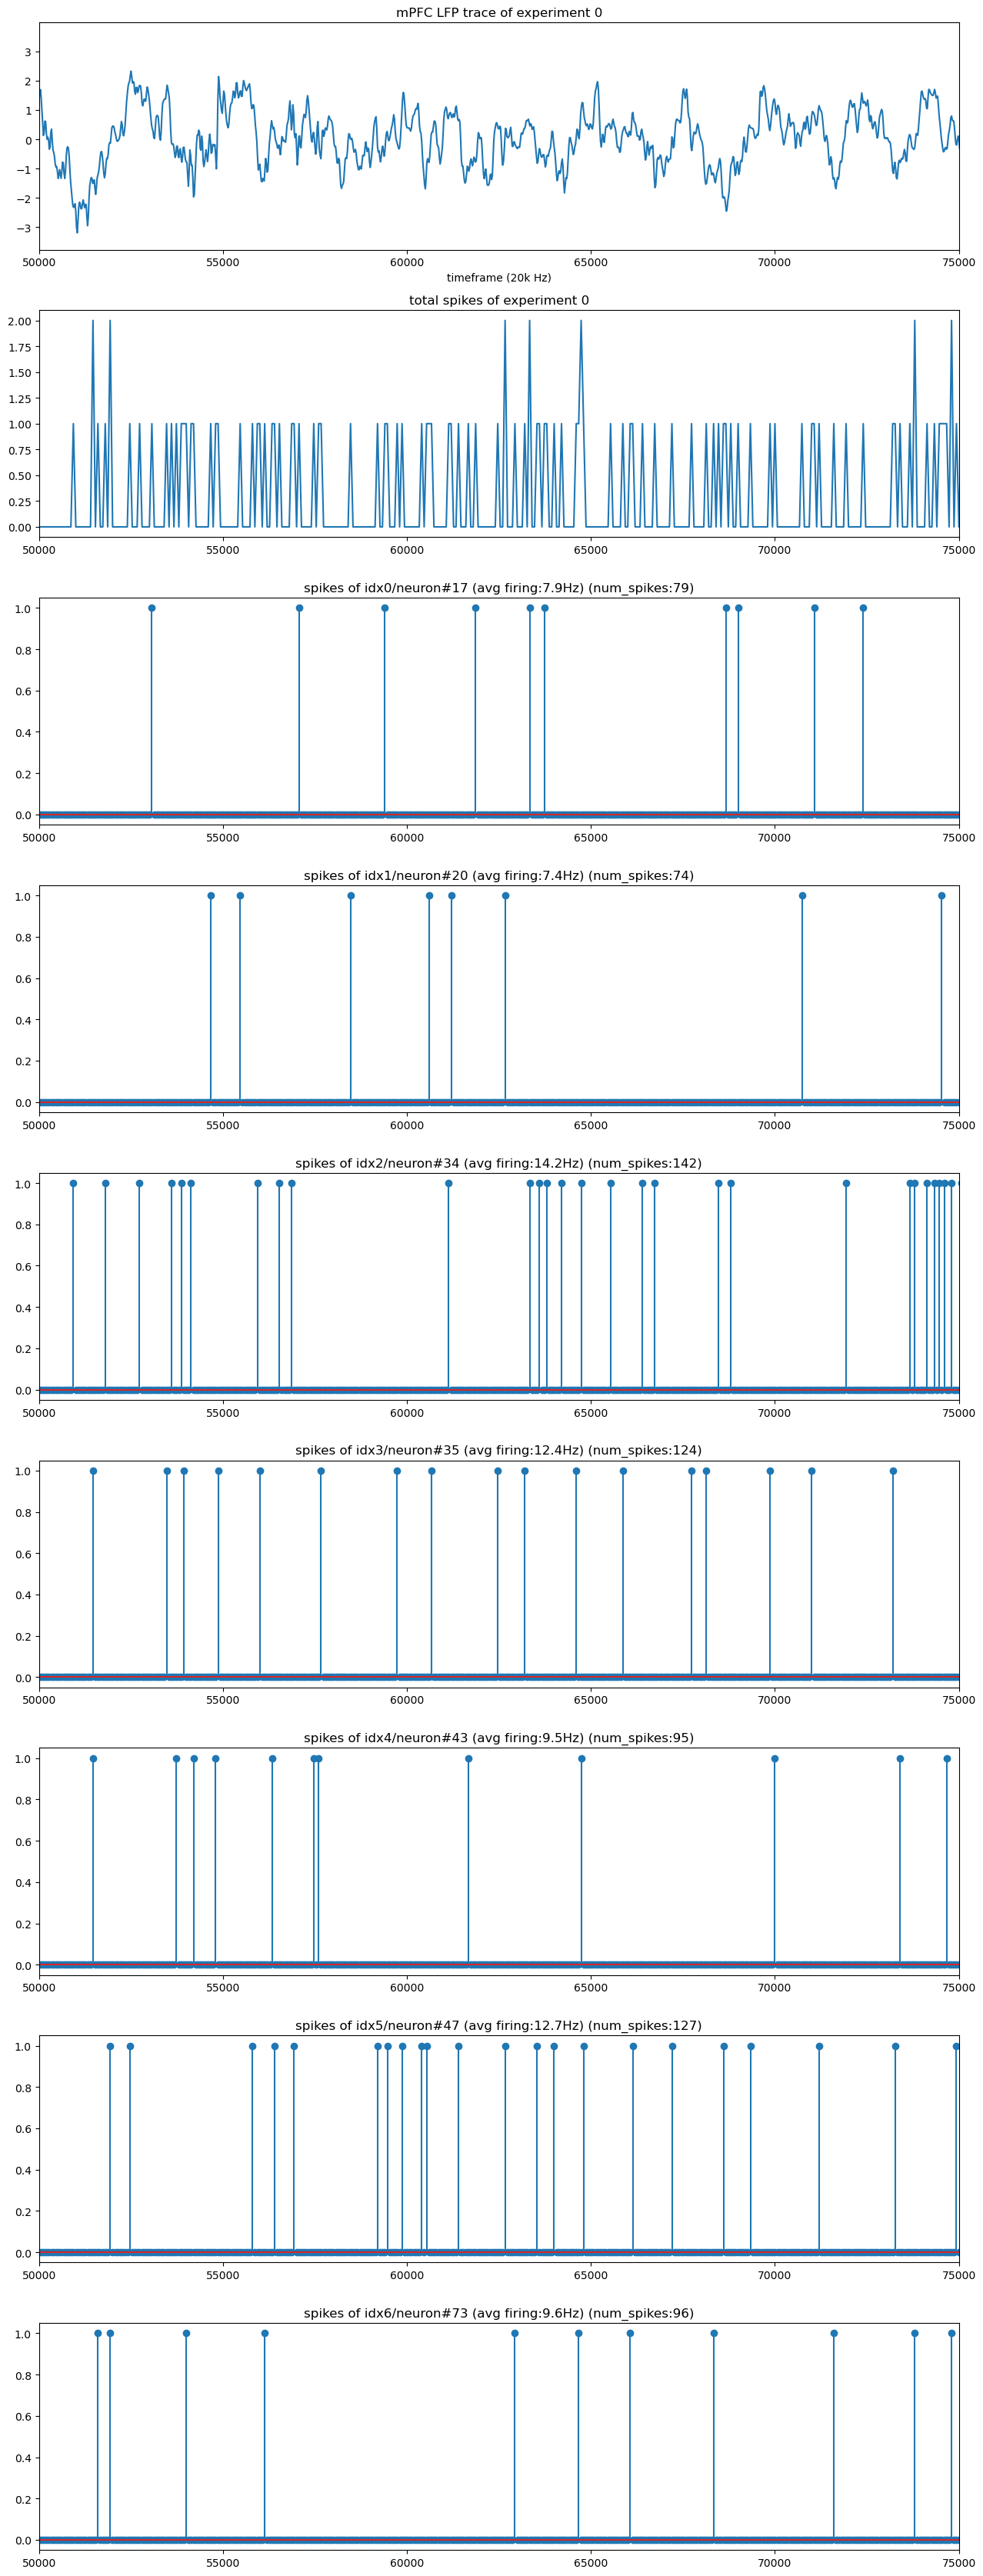

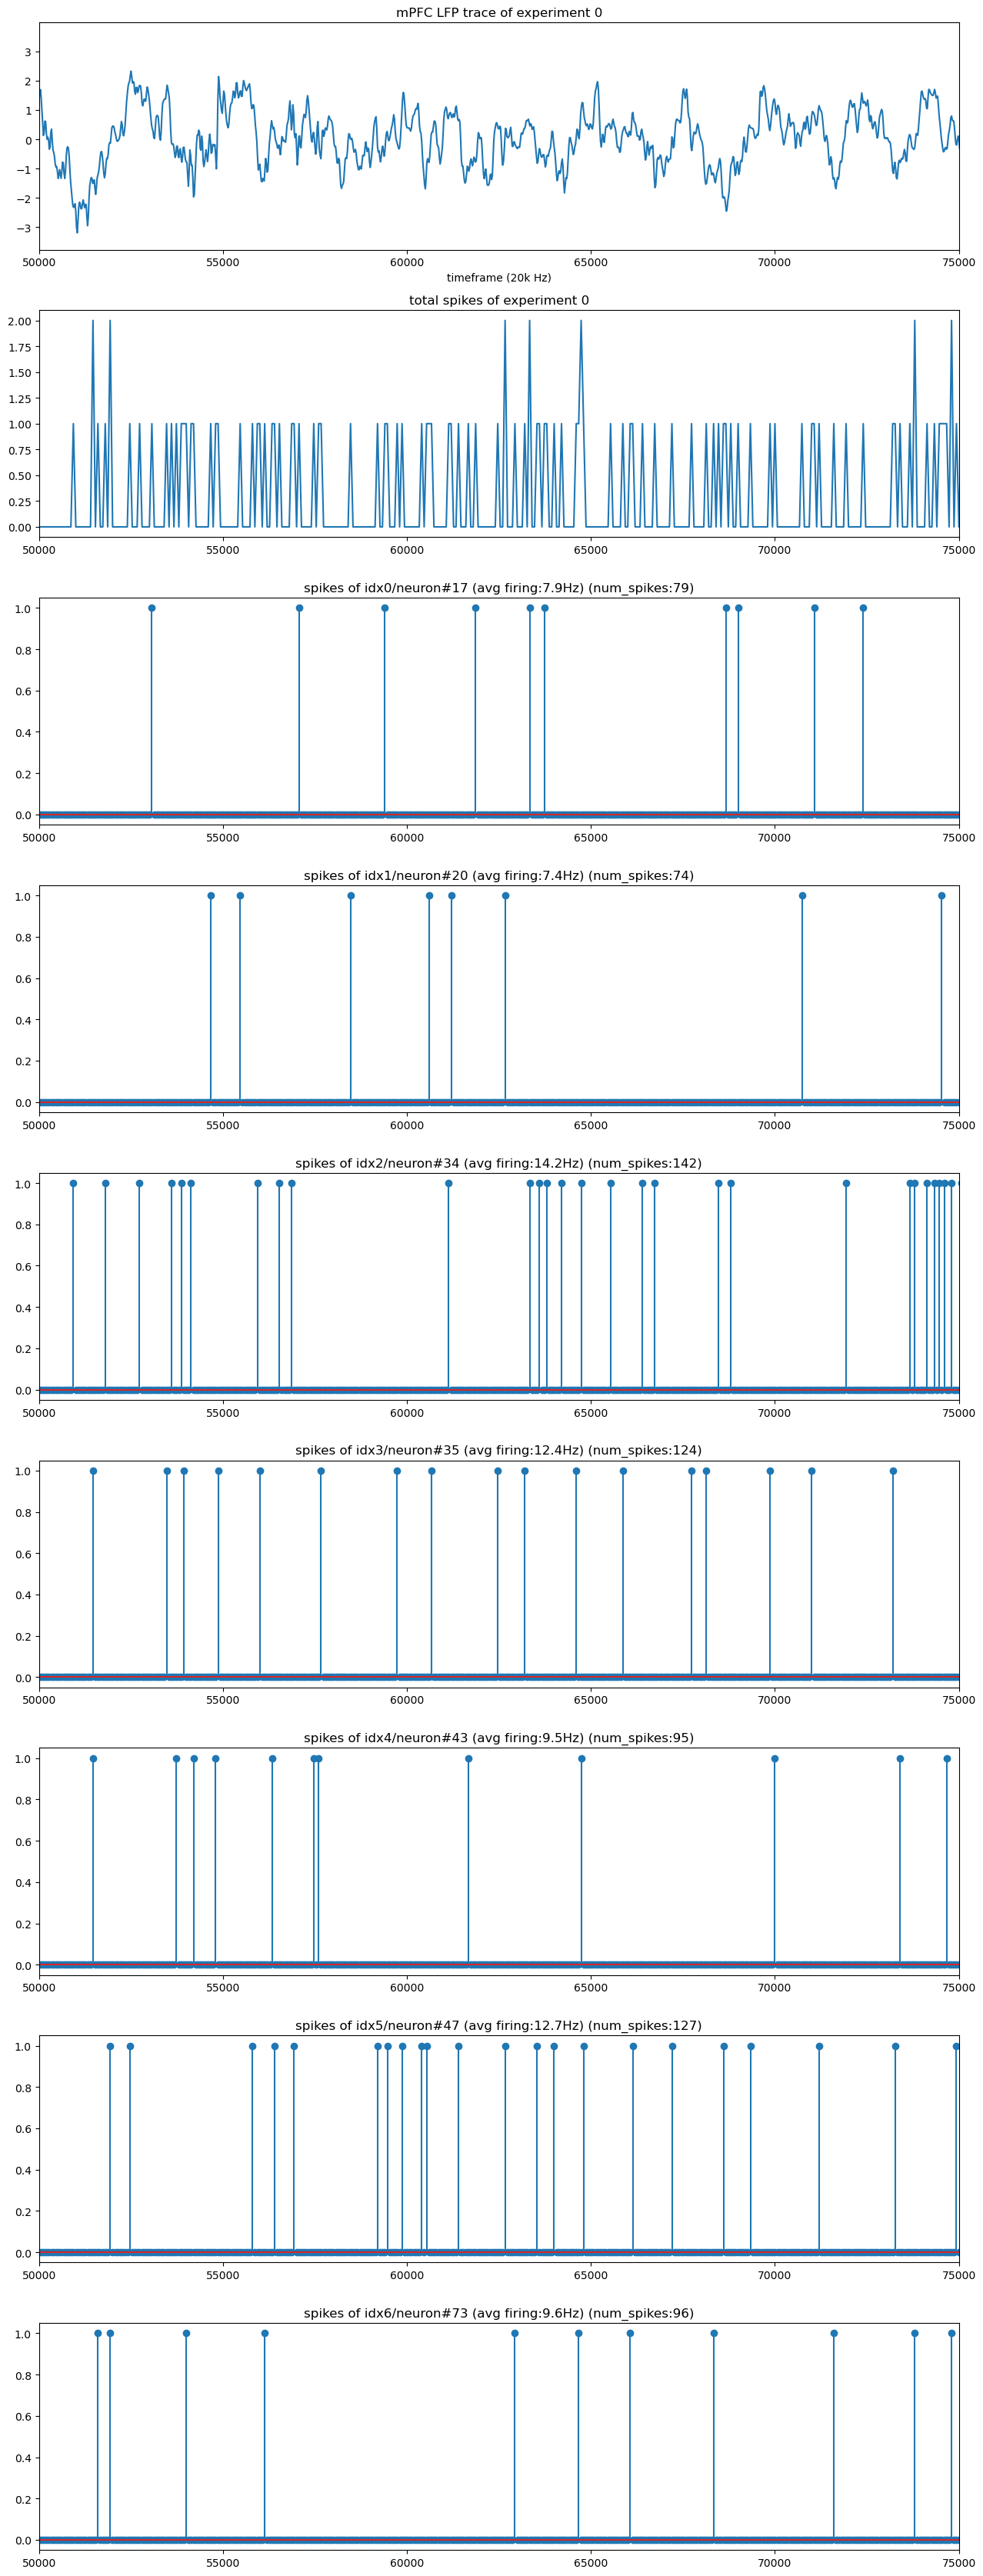

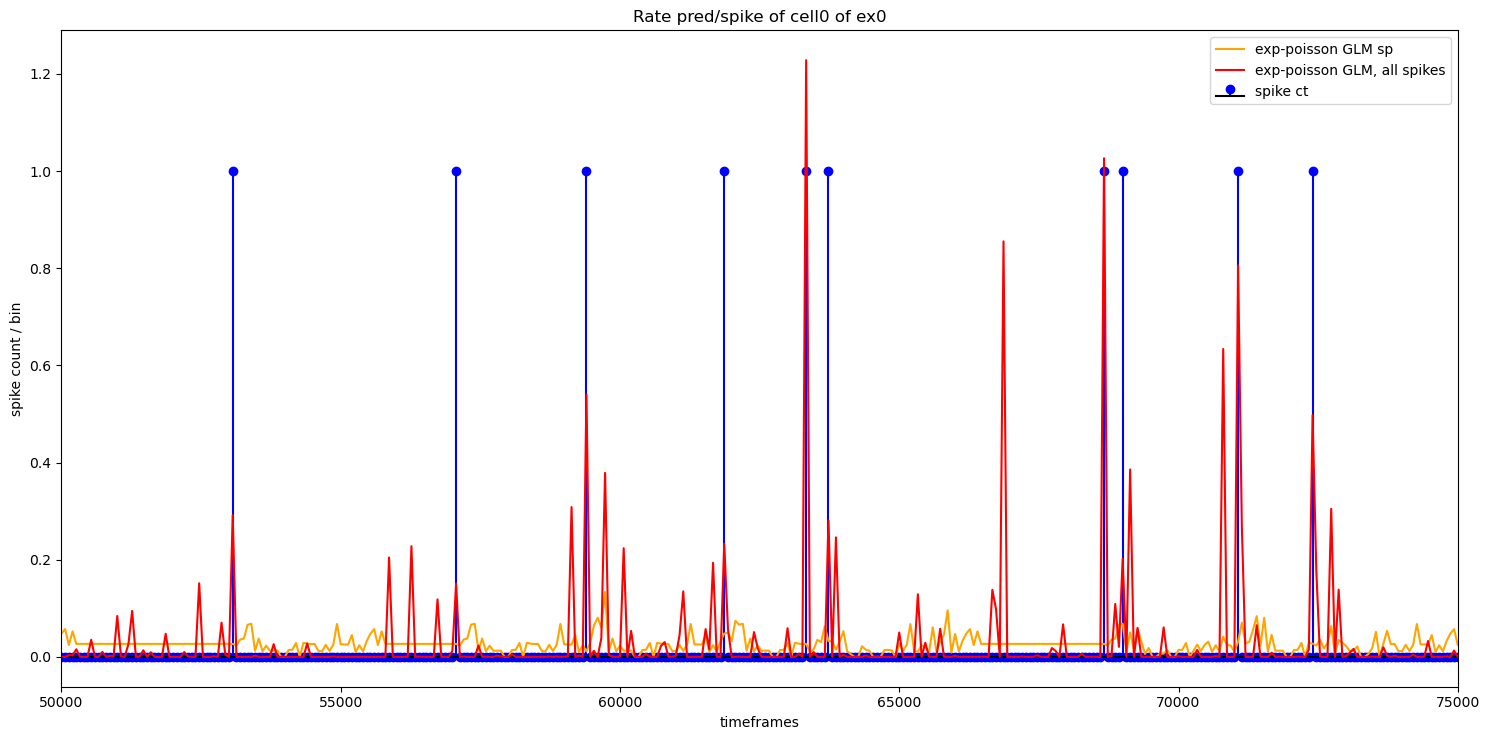

In [10]:
## Use this to see entire length. Modify plot_xlim to narro wover spike range that you are interested in
# dataframe_DesMatPlot(exp_id=0, cell_idx=0, dataframe = df_sess_train)
dataframe_DesMat(exp_id=0, cell_idx = 0, dataframe = df_sess_train, print_trial_info = True, plot_xlim = [50000, 75000])
dataframe_DesMatPlot(exp_id=0, cell_idx=0, dataframe = df_sess_train, inplot_xlim = [50000, 75000], show_input = True)

## Repeat with all spiking from experimental condition: "winning" vs "losing"

In [11]:
# print(df_sess_train["trial_label"])
# print(df_sess_train["experiment"])
exp_dataset = dataframe_DesMat(0,dataframe = df_sess_train)
num_time_bins_spike = exp_dataset["num_time_bins_spike"]
nthist = exp_dataset["nthist"]


windex = np.array([df_sess_train["trial_label"].iloc[idx] == "win" for idx in range(df_sess_train.shape[0])]) # conditions where the mice wins. All others is "lose"
# print(windex)
# print(len(windex))

des_mat = None
des_matF = None

num_cells = 0
first_con = True
for i in range(df_sess_train.shape[0]):
    if windex[i]:
        temp = dataframe_DesMat(i, dataframe=df_sess_train)
    else:
        continue
    des_mat = temp["design_mat_all_spikes"] if first_con else np.hstack((des_mat, temp["design_mat_all_spikes"]))
    first_con = False
    num_cells += temp["num_cells"] # updating total number of cells being trained on 
    # print(f"reshaped desmat shape: {des_mat.shape} nthist {temp["nthist"]}, num_cells {temp["num_cells"]}")
des_mat_offset = np.hstack((np.ones((num_time_bins_spike,1)), des_mat))
print(f"DesMat shape: {des_mat_offset.shape} = (time_bins:{num_time_bins_spike}, (num_cells trained with:{num_cells})*(nthist:{nthist})+1)")

## repeating, for "lose" condition
num_cellsF = 0
first_conF = True
for i in range(df_sess_train.shape[0]):
    if ~windex[i]: # ~ reverses numpy boolean
        temp = dataframe_DesMat(i, dataframe=df_sess_train)
    else:
        continue
    des_matF = temp["design_mat_all_spikes"] if first_conF else np.hstack((des_matF, temp["design_mat_all_spikes"]))
    first_conF = False
    num_cellsF += temp["num_cells"] # updating total number of cells being trained on 
    # print(f"reshaped desmat shape: {des_mat.shape} nthist {temp["nthist"]}, num_cells {temp["num_cells"]}")
des_mat_offsetF = np.hstack((np.ones((num_time_bins_spike,1)), des_matF))
print(f"DesMat shape: {des_mat_offsetF.shape} = (time_bins:{num_time_bins_spike}, (num_cells trained with:{num_cellsF})*(nthist:{nthist})+1)")

DesMat shape: (3000, 2401) = (time_bins:3000, (num_cells trained with:60)*(nthist:40)+1)
DesMat shape: (3000, 2361) = (time_bins:3000, (num_cells trained with:59)*(nthist:40)+1)


In [12]:
df_sess_train.loc[:,["spike_clusters", "trial_label","subject"]].head(20)

,spike_clusters,trial_label,subject
9,"[17, 20, 34, 35, 43, 47, 73]",lose,1.1
41,"[17, 20, 34, 35, 43, 47, 73]",lose,1.2
18,"[29, 59]",win,1.1
26,"[29, 59]",lose,1.2
14,"[29, 59]",lose,1.2
23,"[17, 20, 34, 35, 43, 47, 73]",lose,1.2
50,[139],lose,1.2
24,"[29, 59]",win,1.1
54,[139],win,1.1
53,"[83, 103]",lose,1.2


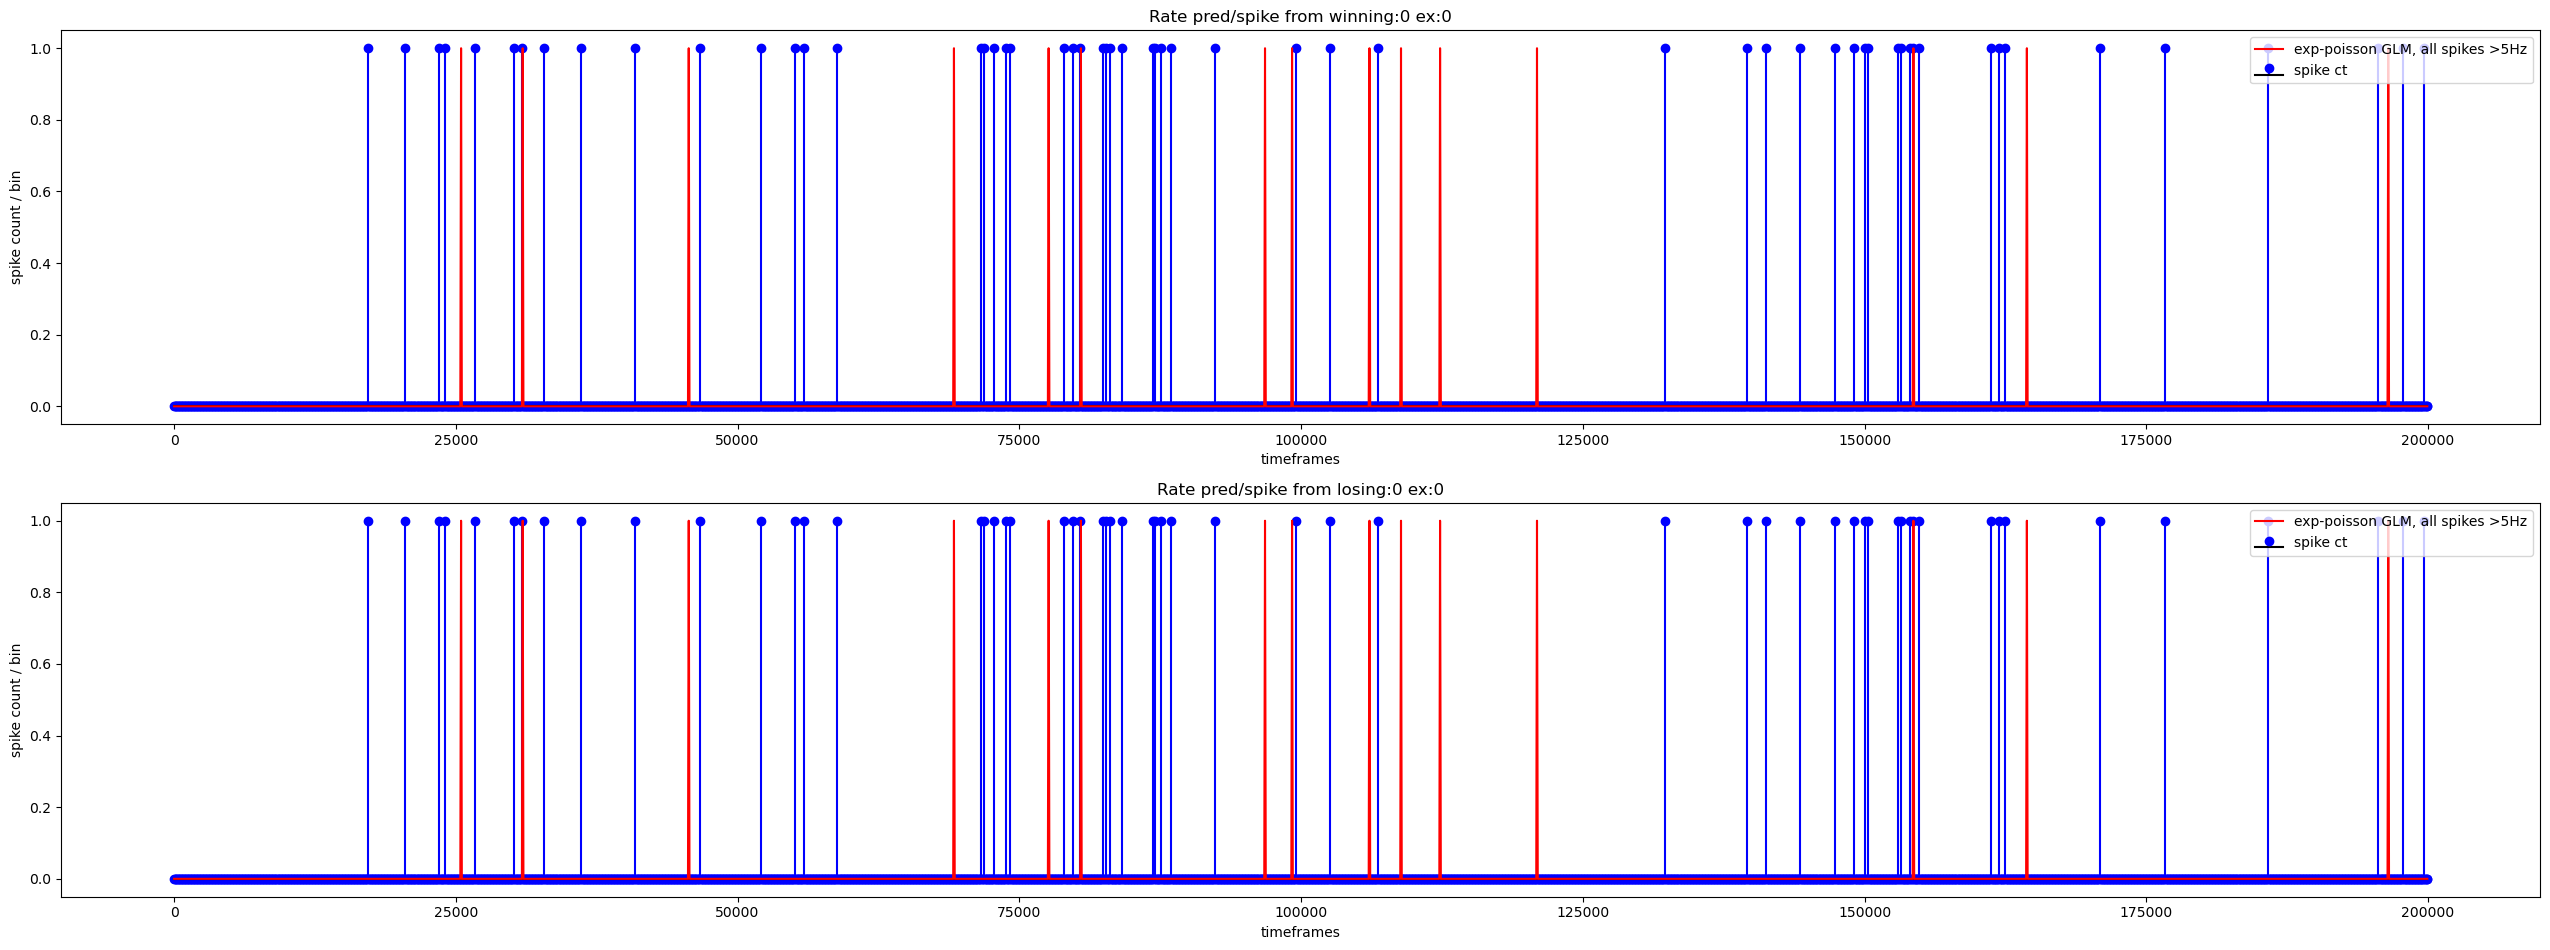

In [13]:
## From DesMat, fit model and plot predictions
## obtaining random neuron as input
import random
train_model = False

neuron_idx = 0
trial_idx = 0

test_trialdict = dataframe_DesMat(trial_idx, cell_idx=neuron_idx, dataframe = df_sess_test, print_trial_info = False)
spikes_binned = test_trialdict["spikes_binned"]
ttplot_spike = np.arange(test_trialdict["num_time_bins_spike"])*test_trialdict["dt_spike"]

if train_model:
    pGLM_allSpike_model = sm.GLM(endog=spikes_binned, exog=des_mat_offset,
                                 family=sm.families.Poisson())
    pGLM_allSpike_results = pGLM_allSpike_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    pGLM_allSpike_modelF = sm.GLM(endog=spikes_binned, exog=des_mat_offsetF,
                                 family=sm.families.Poisson())
    pGLM_allSpike_resultsF = pGLM_allSpike_modelF.fit(max_iter=100, tol=1e-6, tol_criterion='params')

else:
    pGLM_allSpike_results = sm.load('2024-04-27_pGLM_allSpike_wincon.pickle')
    pGLM_allSpike_resultsF = sm.load('2024-04-27_pGLM_allSpike_losscon.pickle')
    

pGLM_allSpike_const = pGLM_allSpike_results.params[0]
pGLM_allSpike_filt = pGLM_allSpike_results.params[1:]
pGLM_allSpike_filt = np.reshape(pGLM_allSpike_filt, (nthist,num_cells), order='F')
# print(f"filter reshape {pGLM_allSpike_filt.shape} (nthist {nthist}, num_cells {num_cells})")
rate_pred_all = np.exp(pGLM_allSpike_const + des_mat @ pGLM_allSpike_results.params[1:])


pGLM_allSpike_constF = pGLM_allSpike_resultsF.params[0]
pGLM_allSpike_filtF = pGLM_allSpike_resultsF.params[1:]
pGLM_allSpike_filtF = np.reshape(pGLM_allSpike_filtF, (nthist,num_cellsF), order='F')
# print(f"filter reshape {pGLM_allSpike_filt.shape} (nthist {nthist}, num_cells {num_cells})")
rate_pred_allF = np.exp(pGLM_allSpike_constF + des_matF @ pGLM_allSpike_resultsF.params[1:])

fig, ax = plt.subplots(2)
fig.set_figheight(4.8*2)
# fig.set_figwidth(12.8)
fig.set_figwidth(12.8*2)
ax[0].stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', label="spike ct")
ax[0].plot(ttplot_spike, rate_pred_all, label=f"exp-poisson GLM, all spikes >{min_freq}Hz", c='red')
# plt.xlim([10000, 50000])
ax[0].set_title(f"Rate pred/spike from winning:{neuron_idx} ex:{trial_idx}")
ax[0].set_ylabel('spike count / bin')
ax[0].set_xlabel('timeframes')
ax[0].legend(loc='upper right')

ax[1].stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', label="spike ct")
ax[1].plot(ttplot_spike, rate_pred_allF, label=f"exp-poisson GLM, all spikes >{min_freq}Hz", c='red')
# plt.xlim([10000, 50000])
ax[1].set_title(f"Rate pred/spike from losing:{neuron_idx} ex:{trial_idx}")
ax[1].set_ylabel('spike count / bin')
ax[1].set_xlabel('timeframes')
ax[1].legend(loc='upper right')

plt.tight_layout()



In [14]:
## Saving Model
# pGLM_allSpike_results.save('2024-04-27_pGLM_allSpike_wincon.pickle')
# pGLM_allSpike_resultsF.save('2024-04-27_pGLM_allSpike_losscon.pickle')
## load with
# pGLM_allSpike_results = sm.load()

## How does this compare to the spiking from data in Baseline?

Data summary for experimental trial idx0
timefr duration: 200000 at 20,000Hz = 10.0s
timeframes btwn. LFP: 20
timeframes btwn. Spikes: 66.66666666666667
num_time_bins (lfp) = 10000 of size 20.0 timeframes or 0.001 seconds
num_time_bins_spike = 3000 of size 66.66666666666667 timeframes or 0.00333 seconds
number of cells: 7
spike_times shape: (7, 169), type: <class 'numpy.ndarray'>
Spike index (7): [17, 20, 34, 35, 43, 47, 73]
Total spikes over condition duration: [48, 138, 65, 85, 78, 168, 133]
Average firing rate per neuron
['4.80', '13.80', '6.50', '8.50', '7.80', '16.80', '13.30']


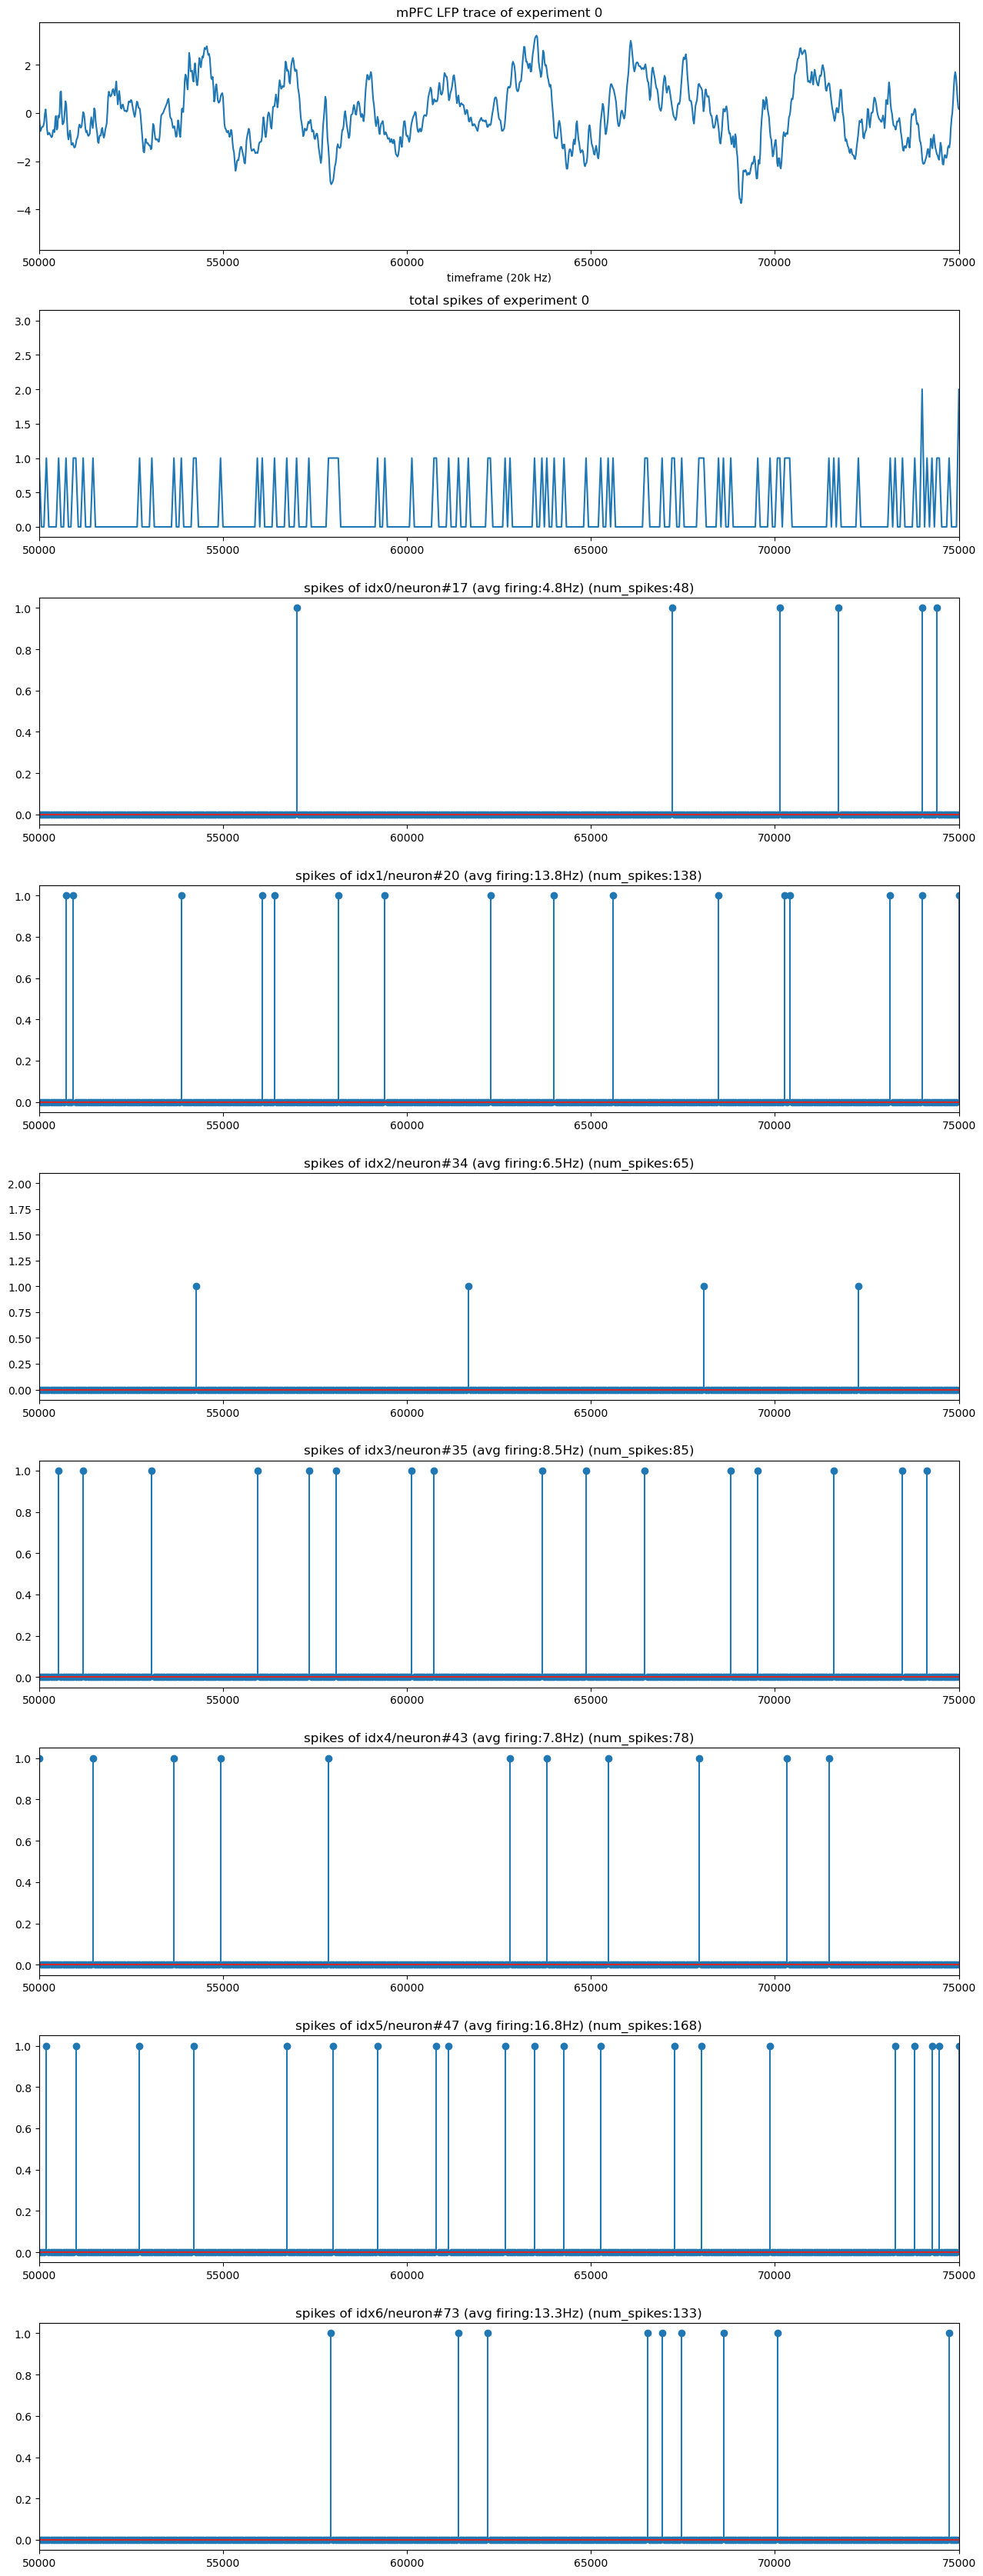

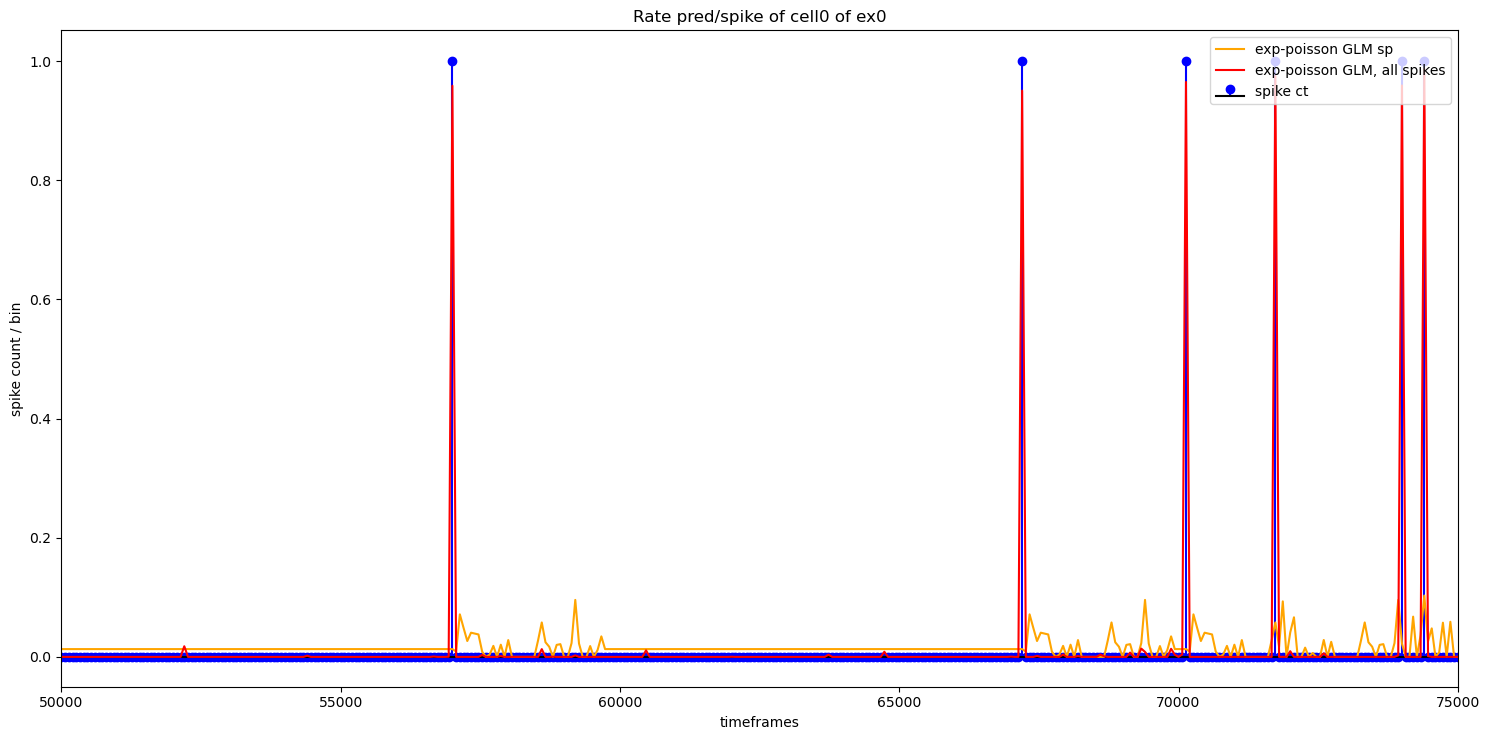

In [15]:
dataframe_DesMatPlot(exp_id=0, cell_idx=0, dataframe = df_sess_train, inplot_xlim = [50000, 75000], show_input = True,timefr_condition_plot = "baseline")


# Prediction by Phase Coherence

model conditional intensity of point process as function of LFP phase: $$\lambda_t=e^{\beta_{0}+\beta_{1}\cos{(\phi(t)})+\beta_{2}\sin{(\phi(t)})}$$ where  
- $\phi(t)$: instantaneous phase of narrowband signal in LFP  
    1. bypass LFP & apply Hilbert transform  
    2. fit GLM to spike train data using canonical log link, to estimate model parameters  
- $\beta_0$ estimates **overall activity of neuron**  
-  $\beta_1$ & $\beta_2$ captures association btwn. **LFP phase & spiking activity**


Steps:
1. Filter LFP data into a narrow band
2. Apply HIlbert Transform to compute instantaneous phase
3. Sort spike data according to phase of LFP

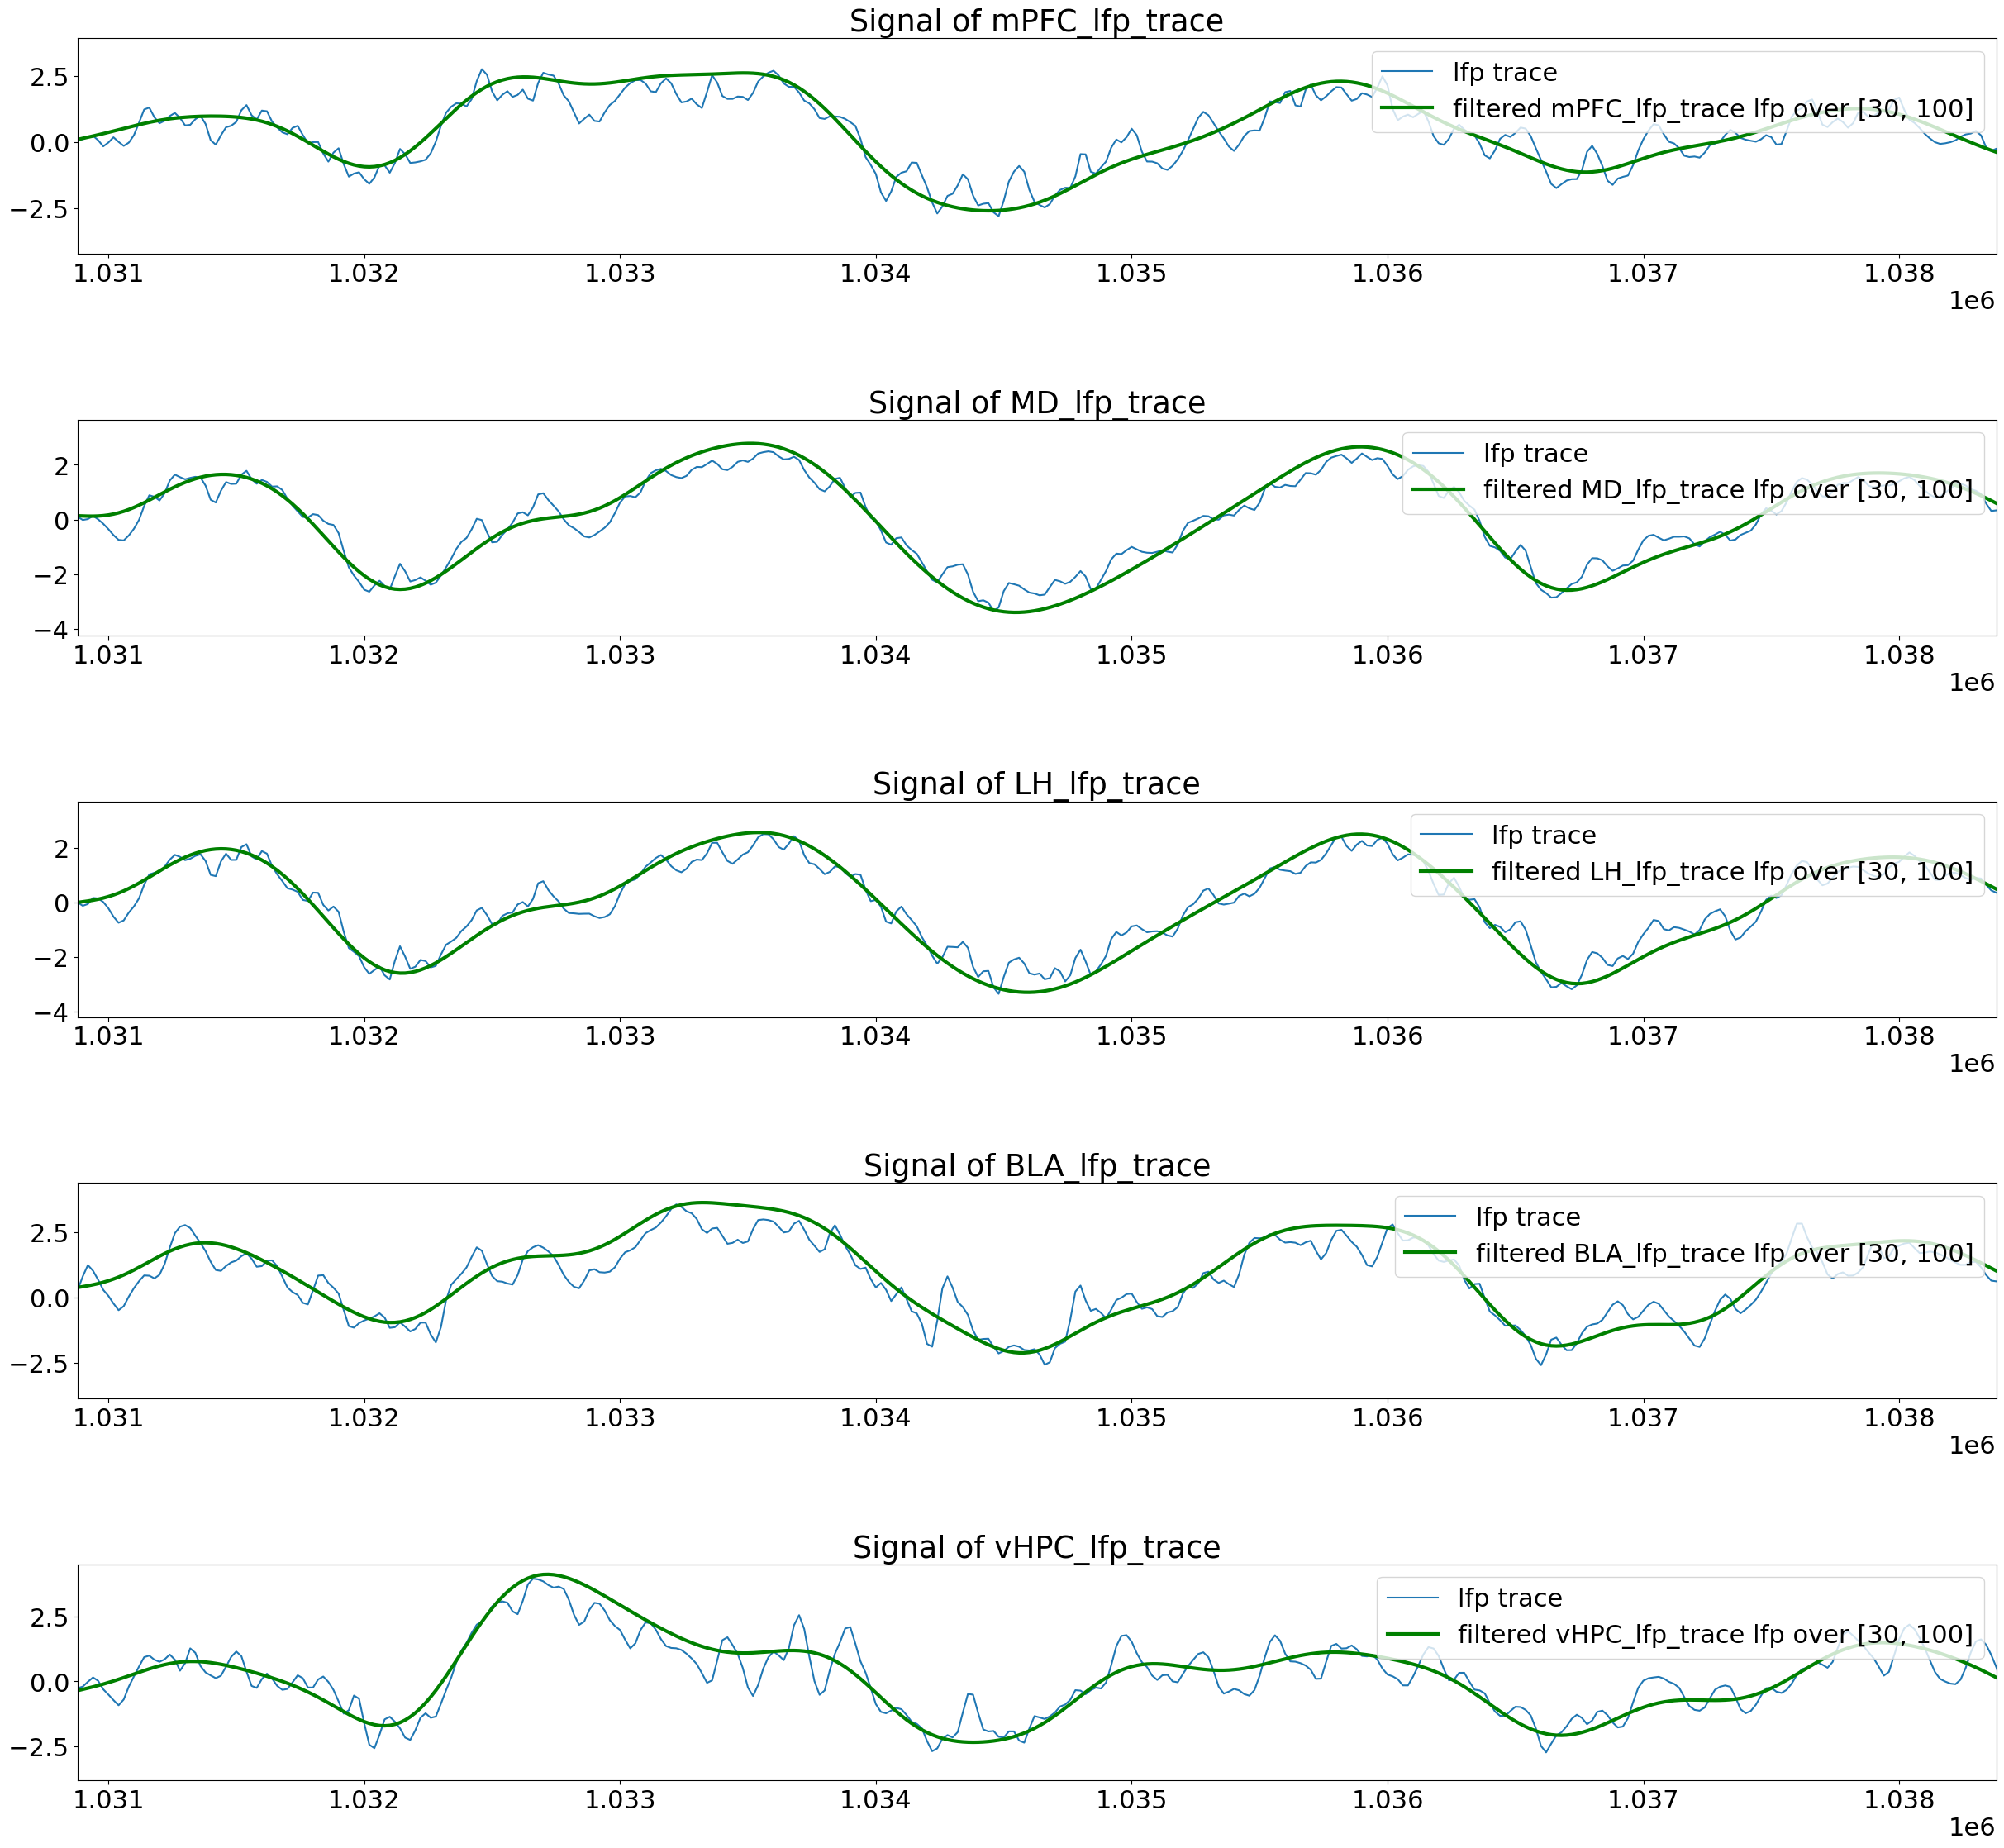

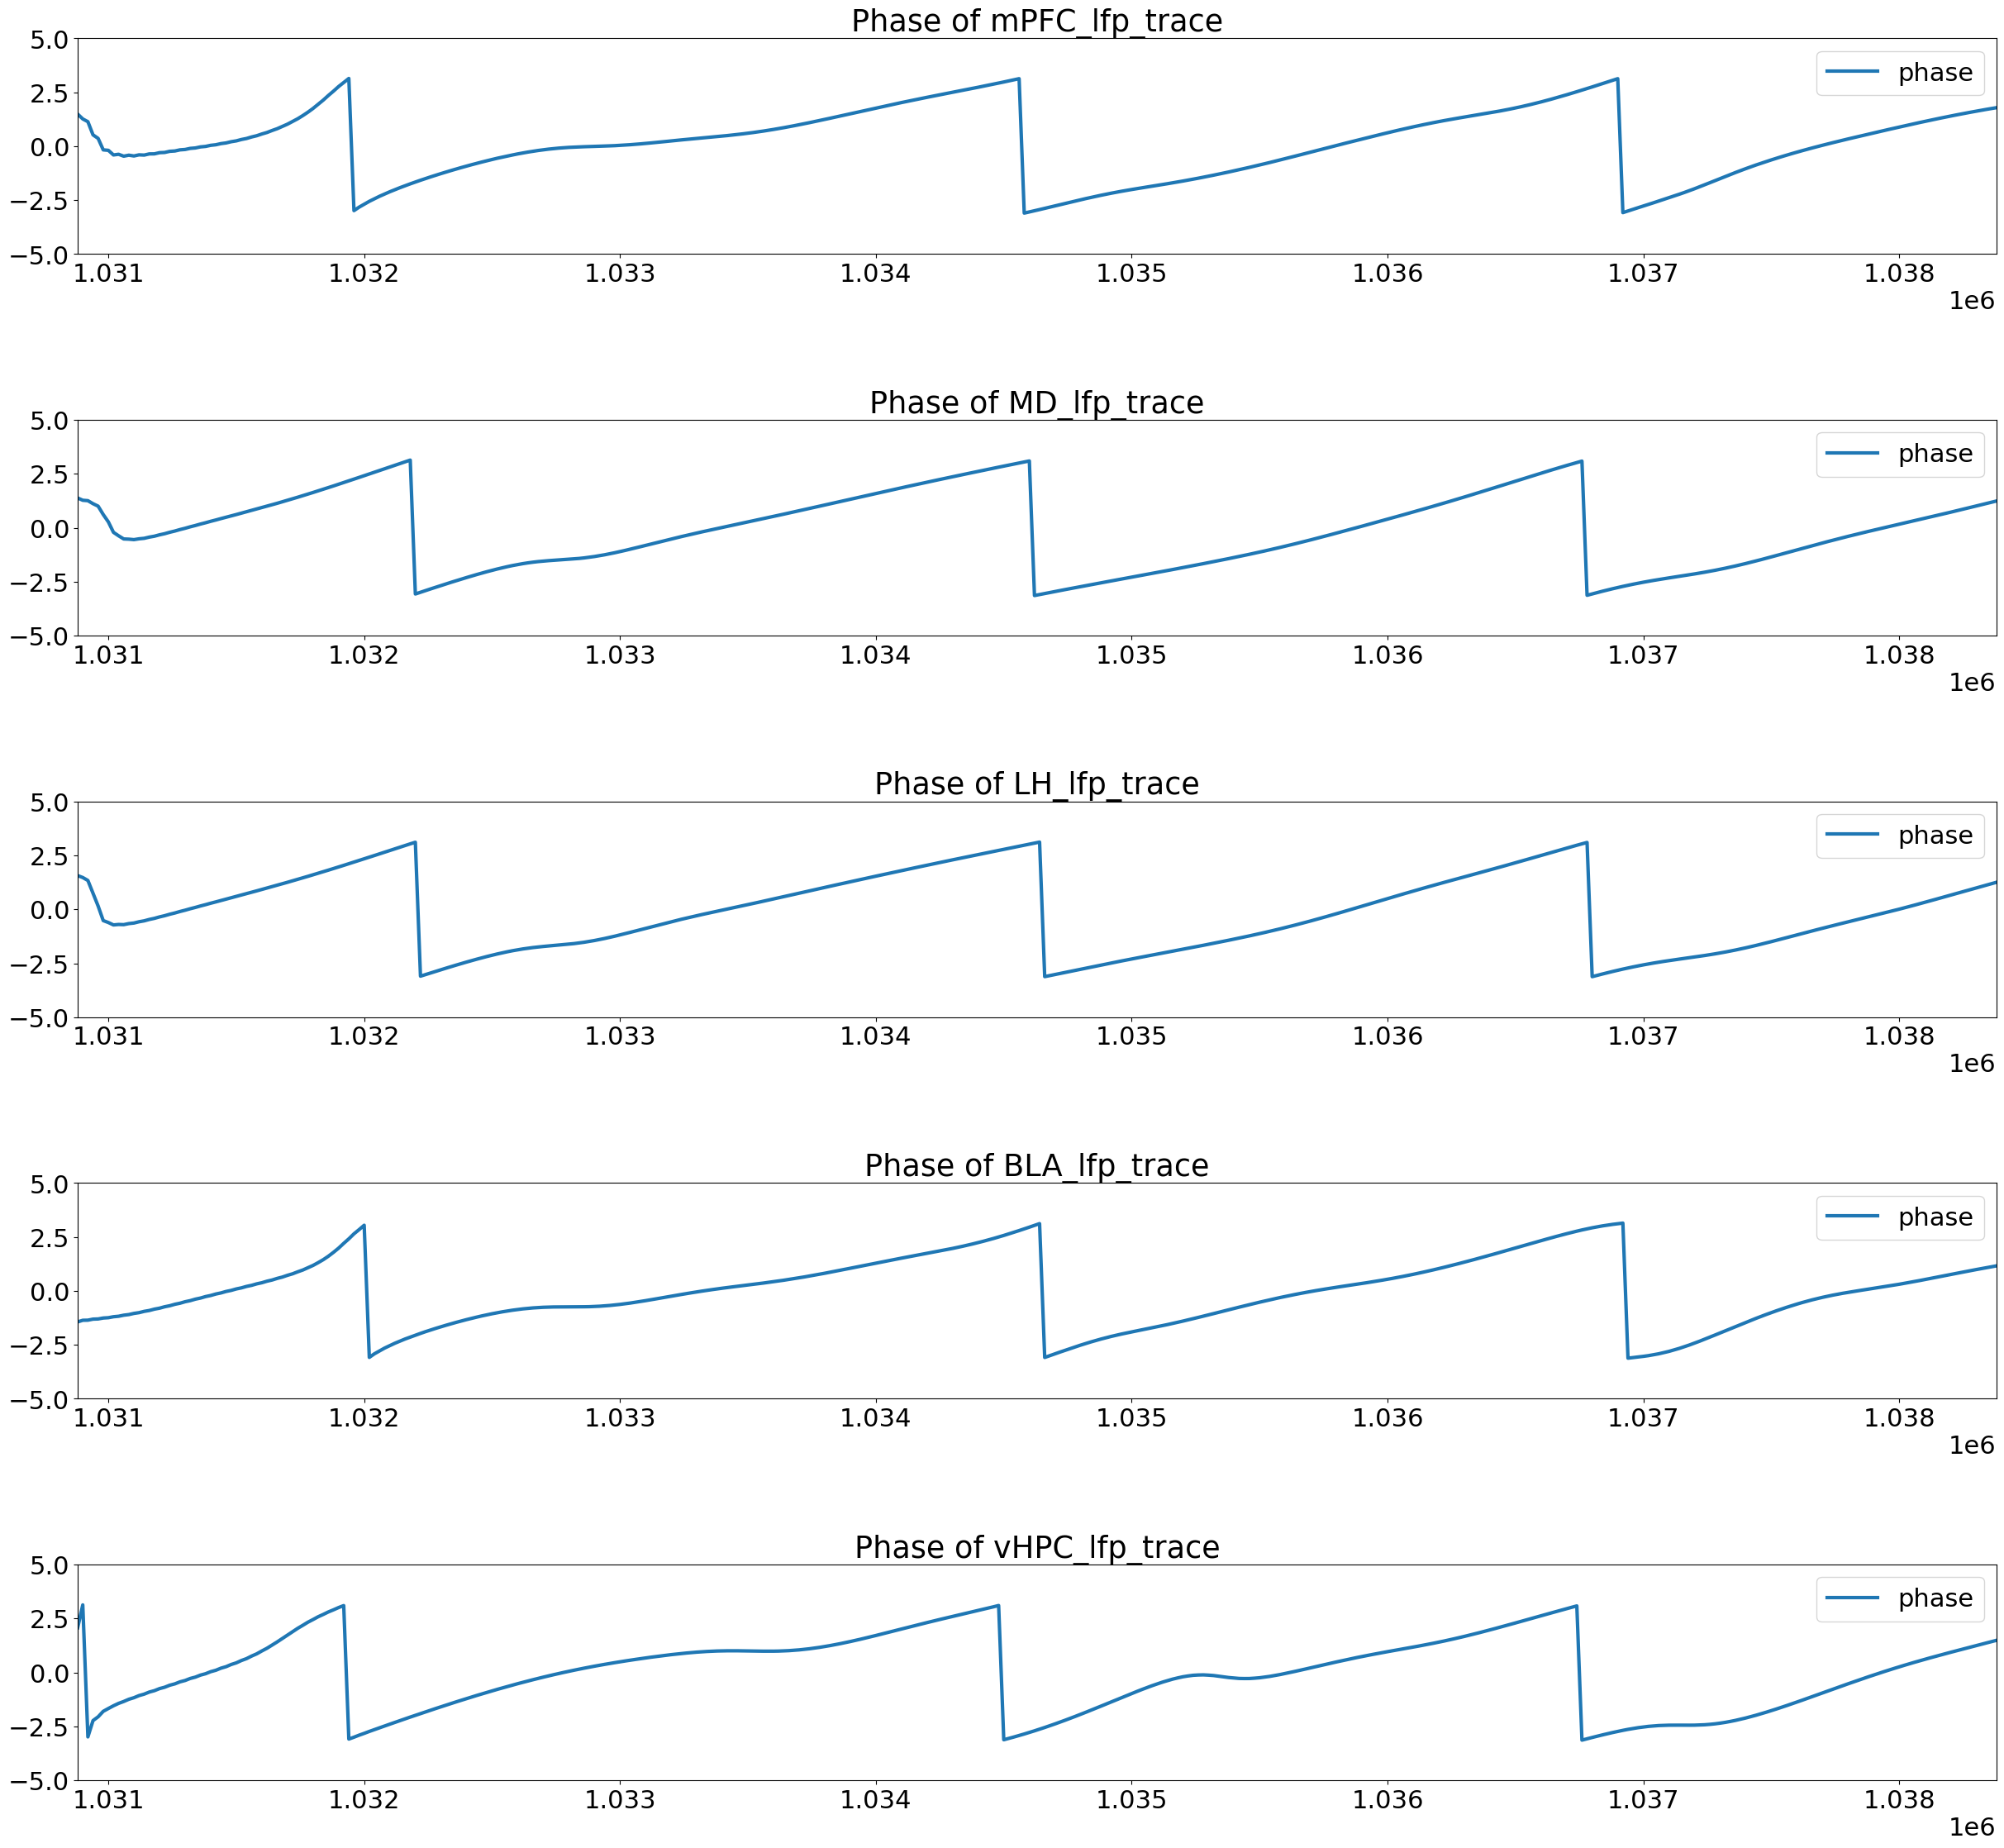

In [16]:
## LFP analysis
from scipy import signal
from scipy.signal import butter, filtfilt, hilbert, lfilter
from scipy.interpolate import interp1d
import math
import itertools
import time

plt.rcParams.update({'font.size': 22}) # default = 10

show_int_plot = False # whether to show interpolation in plot
exp_id = 0 # needed for function: not technically needed
ntfilt = 25 # time bins useed in history analysis
nthist = 40
plot_xlim = [0, 7500]
brain_list = ["mPFC_lfp_trace","MD_lfp_trace","LH_lfp_trace","BLA_lfp_trace","vHPC_lfp_trace"]
num_trials = len(brain_list)

trial_dict = dataframe_DesMat(exp_id, dataframe = TRIALS_AND_SPECTRAL_DF_filt,
                              min_freq = 0, ntfilt = 50, nthist = 40, print_trial_info = False)

spike_times = trial_dict["spike_times"]
total_spikes_binned = trial_dict["total_spikes_binned"]
design_mat_spikes = trial_dict["design_mat_spikes"]
lfp = trial_dict["lfp"]
lfp_times = trial_dict["lfp_times"]
num_time_bins = trial_dict["num_time_bins"]
trial_start_timestamp = TRIALS_AND_SPECTRAL_DF_filt["tone_start_timestamp"].iloc[exp_id]
trial_stop_timestamp = trial_start_timestamp + 10*20000

dt_lfp = lfp_times[1]-lfp_times[0] # size of frame
iiplot = np.arange(len(lfp))
ttplot = iiplot*dt_lfp


## generating LFP phase input
fNQ = 2000 # Nyquist frequency = 2*sampling rate = 2*1000Hz
# Wn = [8,12] # set bandpass. Must be between zero and fs/2 (nyquist)
# Wn = [1,10]
# Wn = [44-46] # no reason: used in Mark Kramer's sample model
Wn = [30,100] # gamma = [30, 100]
num_time_bins = lfp.size
ord = nthist # filter order, which is Length of filter (num of coefficients, i.e. filter order + 1)
b = signal.firwin(ord, Wn, nyq=fNQ, pass_zero=False, window='hamming');
## firwin: FIR filter design using window method


## Interpolator
num_time_bins_int = 3000 # new number of lfp time bins. Original: 10,000 = 1000Hz*10s. Minimum should be Nyquist frequency, 2*1000Hz
ratio = num_time_bins/num_time_bins_int
lfp_times_int = np.linspace(lfp_times[0],lfp_times[-1],num_time_bins_int)


fig, ax = plt.subplots(num_trials, 1, squeeze=False)
fig.set_figheight(4.8*num_trials)
fig.set_figwidth(12.8*2)

phi = np.zeros([num_trials, num_time_bins])
phi_int = np.zeros([num_trials, num_time_bins_int]) # empty array to hold phase
Vlo_int_all = np.zeros([num_trials, num_time_bins_int])

for k in np.arange(num_trials):
    lfp = TRIALS_AND_SPECTRAL_DF_filt[brain_list[k]].iloc[exp_id]
    _, lfp = filter_by_timestamp_range(start=trial_start_timestamp, stop=trial_stop_timestamp, timestamps=lfp_times, items=lfp)

    
    ax[k][0].set_title(f"Signal of {brain_list[k]}")
    ax[k][0].set_xlim(plot_xlim+lfp_times[0])
    ax[k][0].plot(lfp_times, lfp, label='lfp trace')
    
    Vlo = signal.filtfilt(b, 1, lfp)
    phi[k,:] = np.angle(signal.hilbert(Vlo))
    ax[k][0].plot(lfp_times,Vlo,'g',label=f"filtered {brain_list[k]} lfp over {Wn}",linewidth=3)
    
    Vlo_intfunc = interp1d(lfp_times, Vlo, kind='cubic')
    Vlo_int = Vlo_intfunc(lfp_times_int)
    Vlo_int_all[k,:] = Vlo_int
    phi_int[k,:] = np.angle(signal.hilbert(Vlo_int)) # compute phase

    
    if show_int_plot: ax[k][0].plot(lfp_times_int,Vlo_int,'ro', markersize=3, label="interpolated filtered LFP")
    ax[k][0].legend(loc="upper right")
plt.tight_layout(pad=3)
    # ax[k][0].plot(dt_lfp*np.arange(len(Vlo_int)),Vlo_int,'o',markersize=4,label=f"filtered lfp int at {num_time_bins} -> {num_time_bins_int}")
    # ax[k][0].legend(loc="upper right")

fig, ax = plt.subplots(num_trials, 1, squeeze=False)
fig.set_figheight(4.8*num_trials)
fig.set_figwidth(12.8*2)
for k in np.arange(num_trials):
    ax[k][0].set_title(f"Phase of {brain_list[k]}")
    ax[k][0].set_xlim(plot_xlim+lfp_times[0])
    ax[k][0].set_ylim([-5, 5])
    ax[k][0].plot(lfp_times, phi[k,:], linewidth=3, label='phase')
    if show_int_plot: ax[k][0].plot(lfp_times_int, phi_int[k,:], 'o', label='phase from interpolation')
    ax[k][0].legend(loc="upper right")
plt.tight_layout(pad=3)

[mPFC_lfp_trace]    p-value of sin: 0.37    p-value of cos: 0.89
p-value of null: 0.67
[MD_lfp_trace]    p-value of sin: 0.49    p-value of cos: 0.89
p-value of null: 0.78
[LH_lfp_trace]    p-value of sin: 0.38    p-value of cos: 0.92
p-value of null: 0.67
[BLA_lfp_trace]    p-value of sin: 0.44    p-value of cos: 0.68
p-value of null: 0.68
[vHPC_lfp_trace]    p-value of sin: 0.64    p-value of cos: 0.87
p-value of null: 0.88


<Figure size 640x480 with 0 Axes>

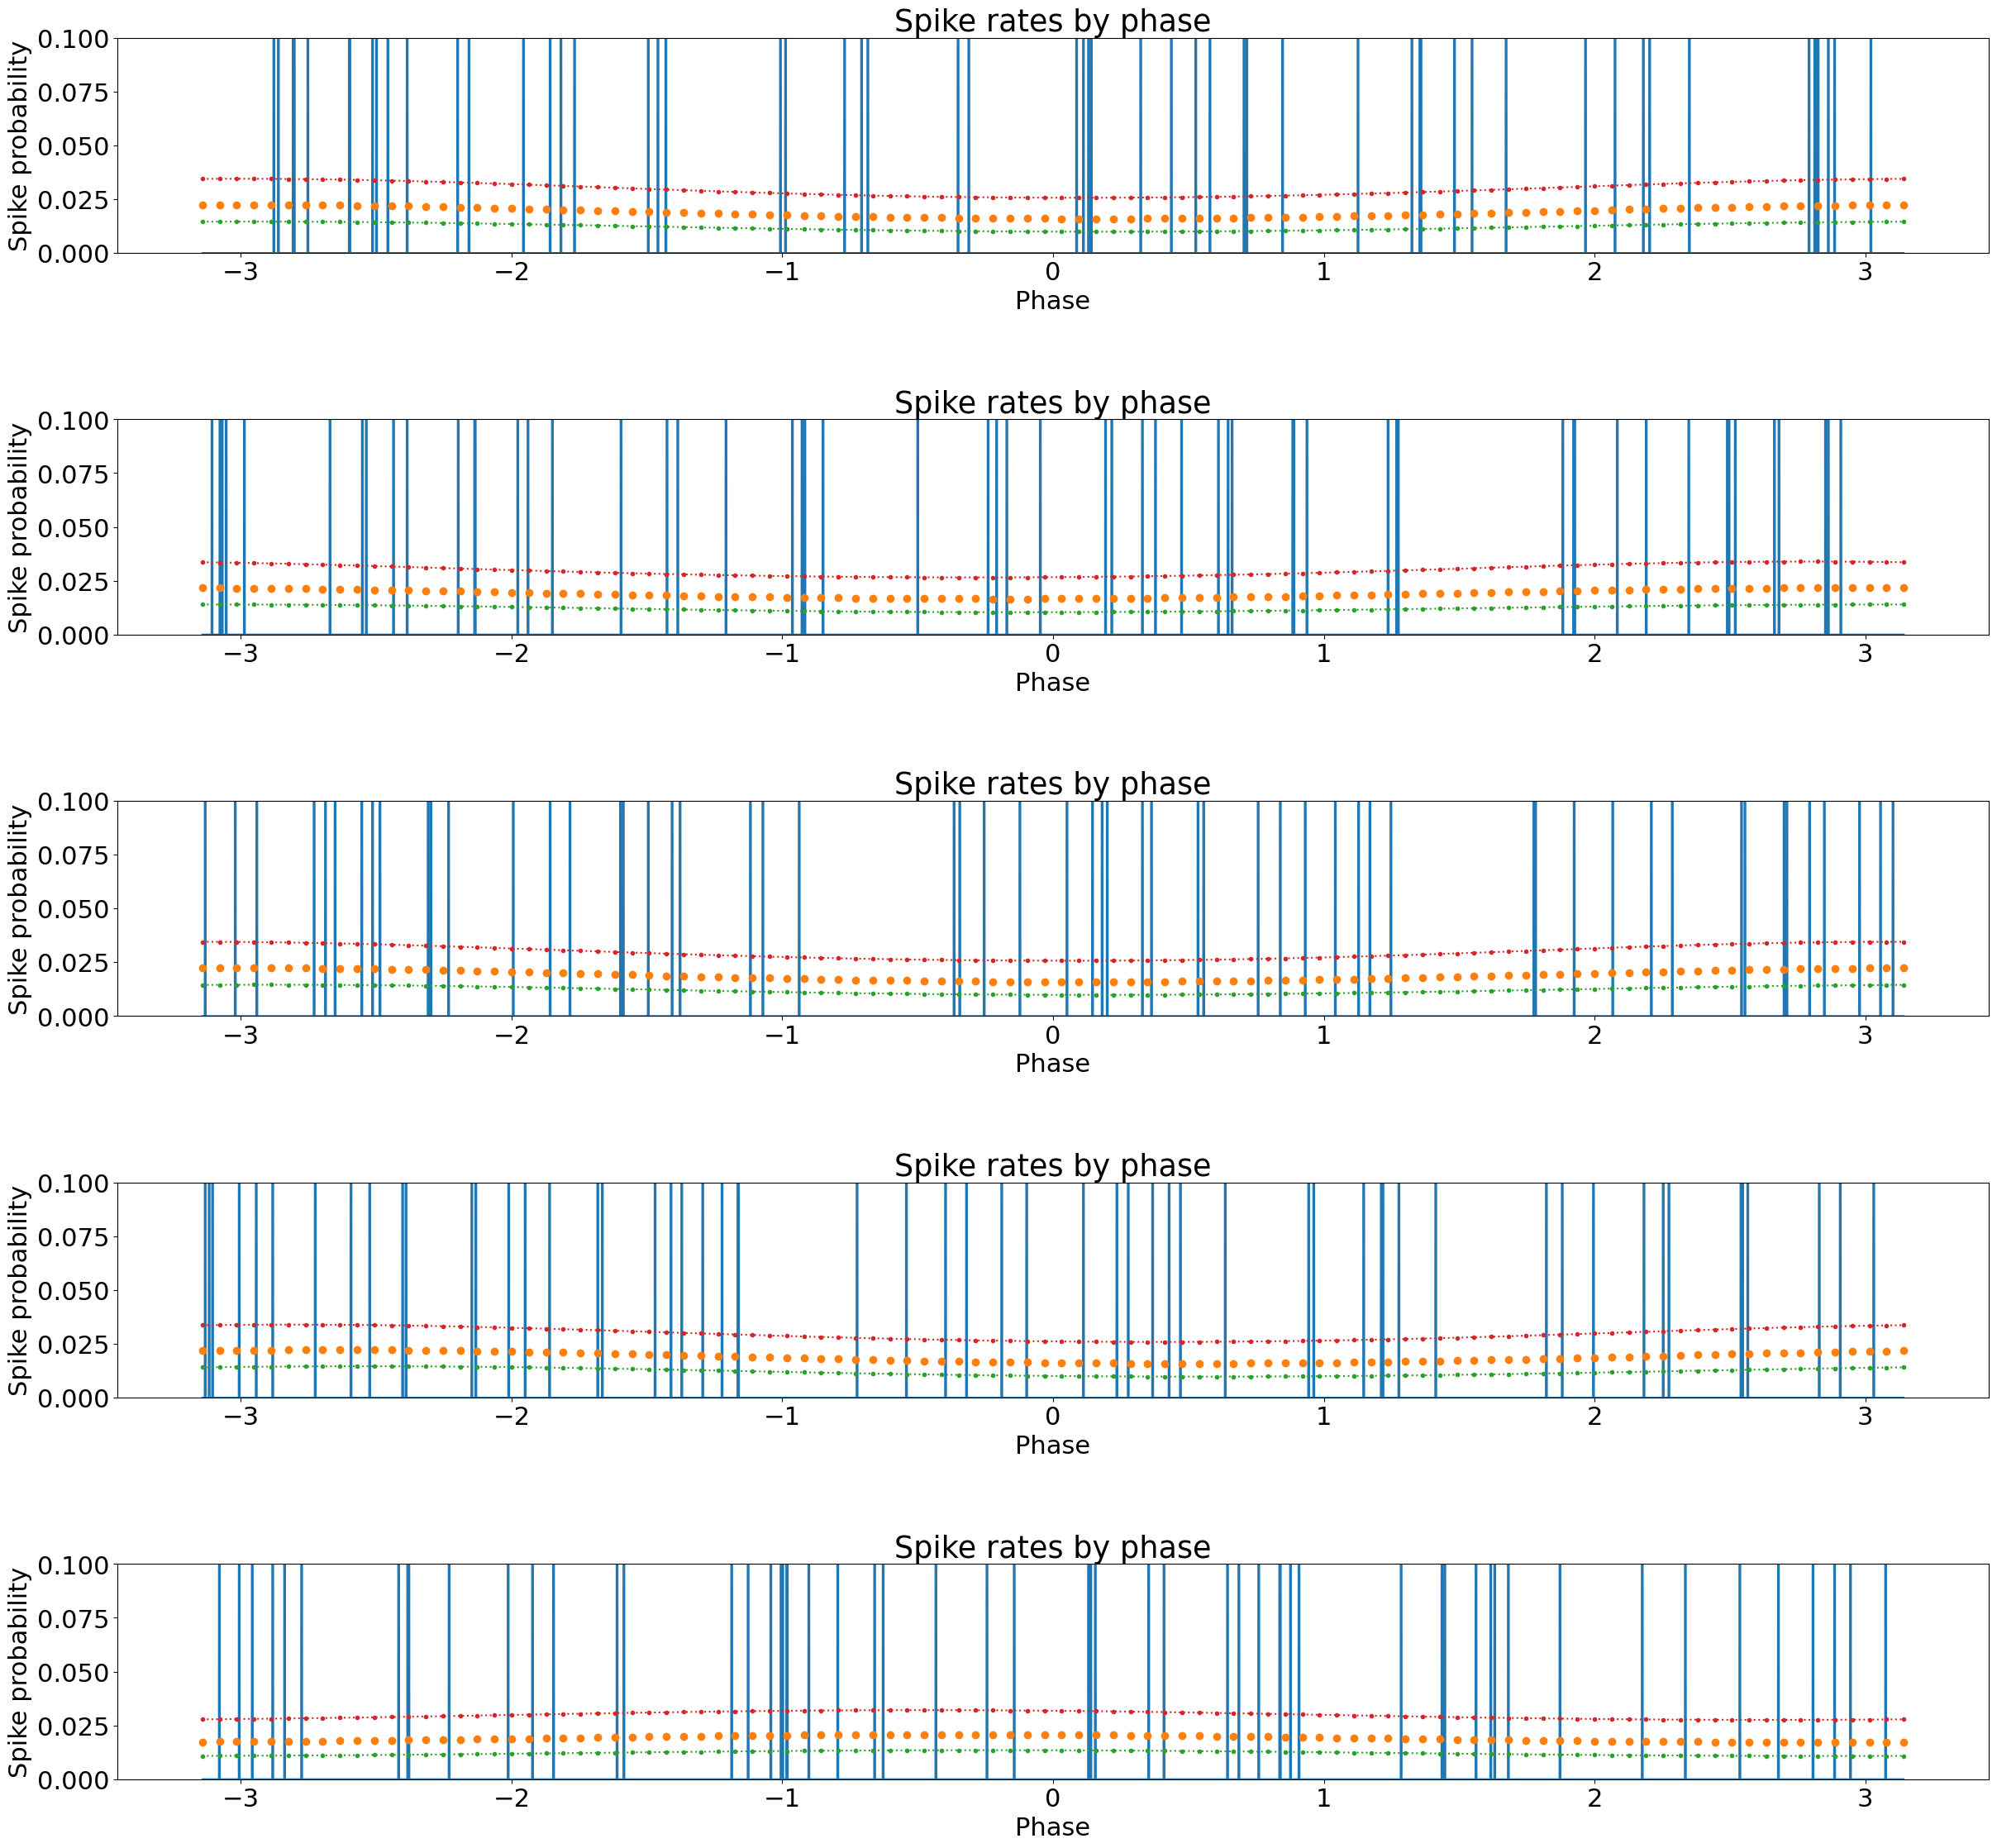

In [17]:
from scipy import stats

dt_lfp = lfp_times_int[1]-lfp_times_int[0] # size of frame
iiplot = np.arange(len(lfp_times_int))
ttplot = iiplot*dt_lfp

plt.clf()
fig, ax = plt.subplots(num_trials, 1, squeeze=False)
fig.set_figheight(4.8*num_trials)
fig.set_figwidth(12.8*2)

for k in np.arange(num_trials):
    phi_int_reshaped = phi_int[k,:]
    phi_int_reshaped = np.reshape(phi_int_reshaped, -1)
    # print(phi_int_reshaped.shape)
    
    X = np.transpose([np.ones(np.shape(phi_int_reshaped)), np.cos(phi_int_reshaped), np.sin(phi_int_reshaped)])
    Y = np.transpose([spikes_binned])
    pGLMphi_model = sm.GLM(Y,X,family=sm.families.Poisson())    # Build the GLM model,
    pGLMphi_results   = pGLMphi_model.fit(max_iter=100, tol=1e-6, tol_criterion='params') 
    phi_predict = np.linspace(-np.pi, np.pi, 100) # x-axis, for plotting
    X_predict = np.transpose([np.ones(np.shape(phi_predict)), np.cos(phi_predict), np.sin(phi_predict)])
    Y_predict = pGLMphi_results.get_prediction(X_predict, linear='False')

    indices = np.argsort(phi_int_reshaped)
    FTA = spikes_binned[indices]
    ax[k][0].plot(np.linspace(-np.pi,np.pi,num_time_bins_int),FTA, markersize=1.5 ,label="FTA spikes")
    ax[k][0].plot(phi_predict, Y_predict.predicted_mean, 'o', markersize=6, label="pred")
    ax[k][0].plot(phi_predict, Y_predict.conf_int(), 'o:', markersize=3, label="pred confidence")
    ax[k][0].set_ylim([0, 0.1])
    ax[k][0].set_xlabel("Phase")
    ax[k][0].set_ylabel("Spike probability")
    ax[k][0].set_title("Spike rates by phase")

    
    ## p-value of parameters
    pval1 = pGLMphi_results.pvalues[1]; # significance of parameter beta_1
    pval2 = pGLMphi_results.pvalues[2]; # significance of parameter beta_2
    print(f"[{brain_list[k]}]    p-value of sin: {pval1:.2f}    p-value of cos: {pval2:.2f}")

    ## comparison against model independent of LFP (i.e. B1=0, B2=0)
    X0 = np.ones(np.shape(Y)) # equal to model where beta_1 and beta_2 are set as zero
    null_model = sm.GLM(Y, X0, family=sm.families.Poisson())
    null_res = null_model.fit()
    pval_null = 1-stats.chi2.cdf(null_res.deviance-pGLMphi_results.deviance,2)
    print(f"p-value of null: {pval_null:.2f}") # value is low, so it's unlikely that our big model were to occur if the reduced model was correct
plt.tight_layout(pad=3)

From results, we see a statistical significance of spike firing rate on the cosine of LFP phase for all three brain regions.

"Under null hypothesis that data arise from a smaller model (generating by setting parameters to constant values), the difference in deviance btwn. the two models should have a chi-ssquare distribution where the number of degrees of freedom is equal to the number of extra parameters in the larger model."

# History-dependent phase


In [18]:
def array_info(array, show = False):
    print(f"Array type:{type(array)}")
    if isinstance(array, (np.ndarray, np.generic, pd.DataFrame)):
        print(f"Shape: {array.shape}")
    elif isinstance(array, (list)):
        print(f"Shape: { np.asarray(array).shape}")

    if (show) and (isinstance(array, (int, np.ndarray, np.generic, list))):
        print(array)

[mPFC_lfp_trace]    p-value of sin: 0.37    p-value of cos: 0.89
p-value of null: 0.67
[MD_lfp_trace]    p-value of sin: 0.49    p-value of cos: 0.89
p-value of null: 0.78
[LH_lfp_trace]    p-value of sin: 0.38    p-value of cos: 0.92
p-value of null: 0.67
[BLA_lfp_trace]    p-value of sin: 0.44    p-value of cos: 0.68
p-value of null: 0.68
[vHPC_lfp_trace]    p-value of sin: 0.64    p-value of cos: 0.87
p-value of null: 0.88
(3000,)
(3000,)
(3000,)
(3000,)
(3000,)


<Figure size 640x480 with 0 Axes>

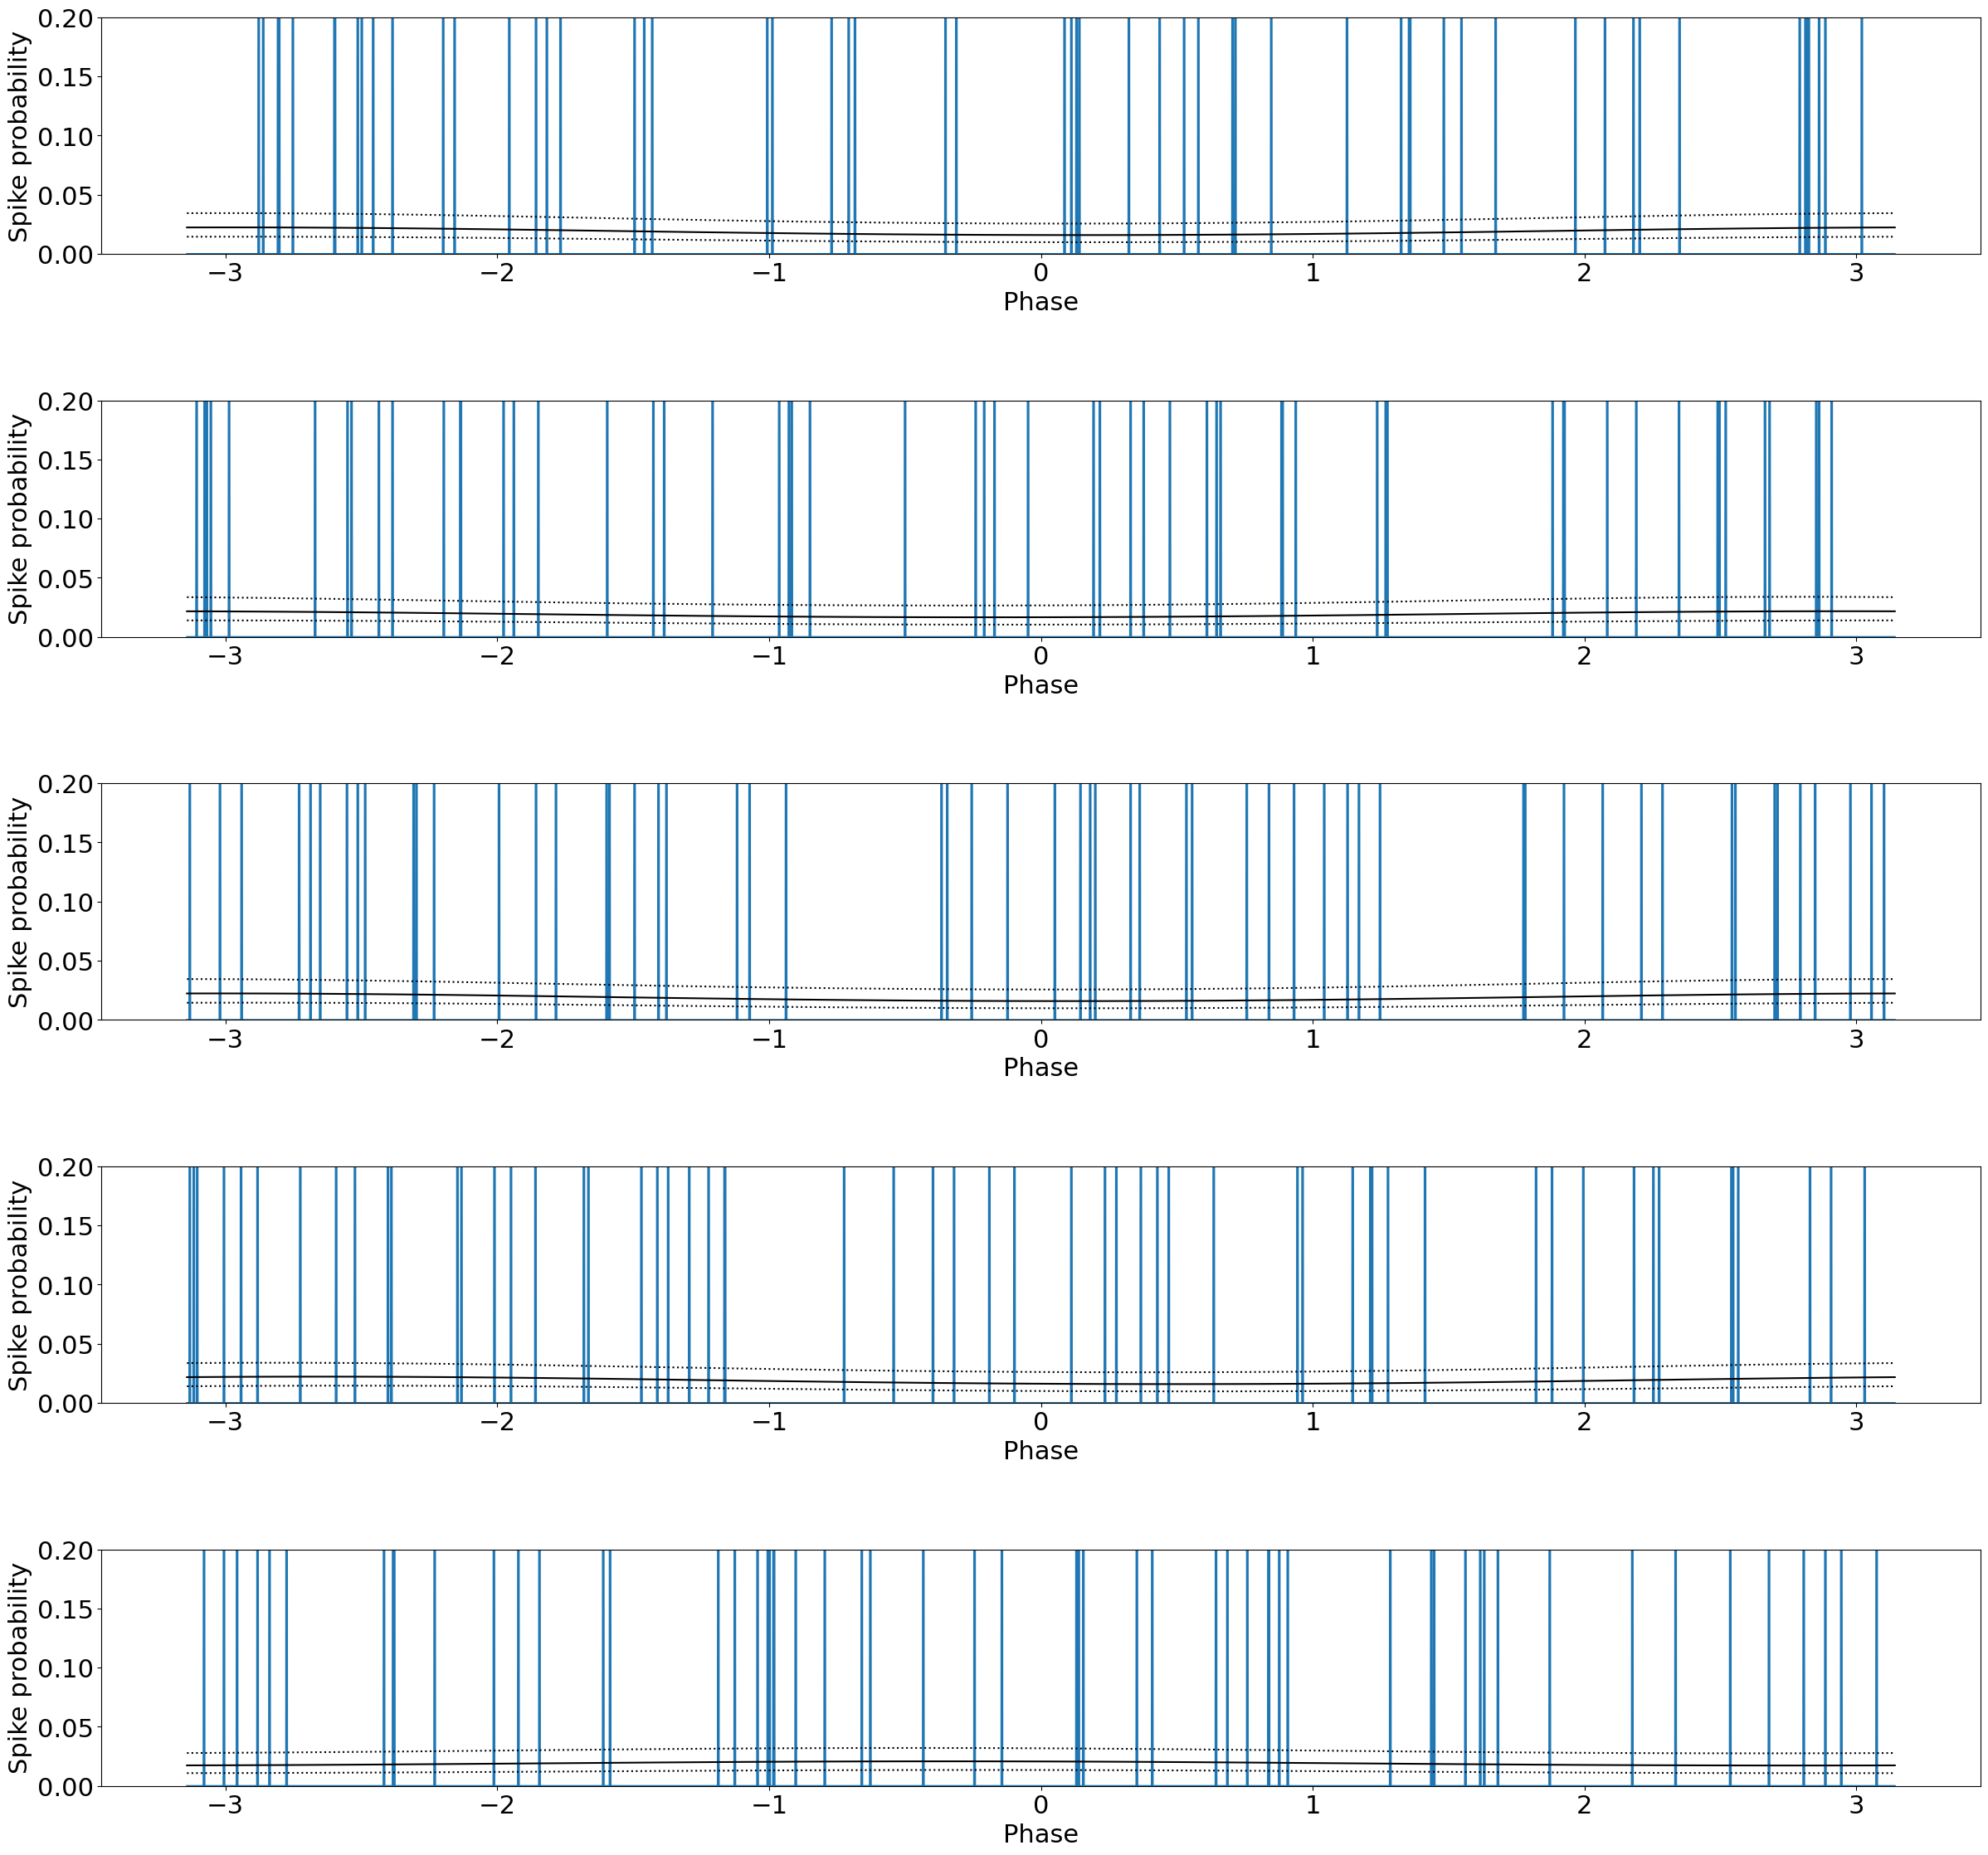

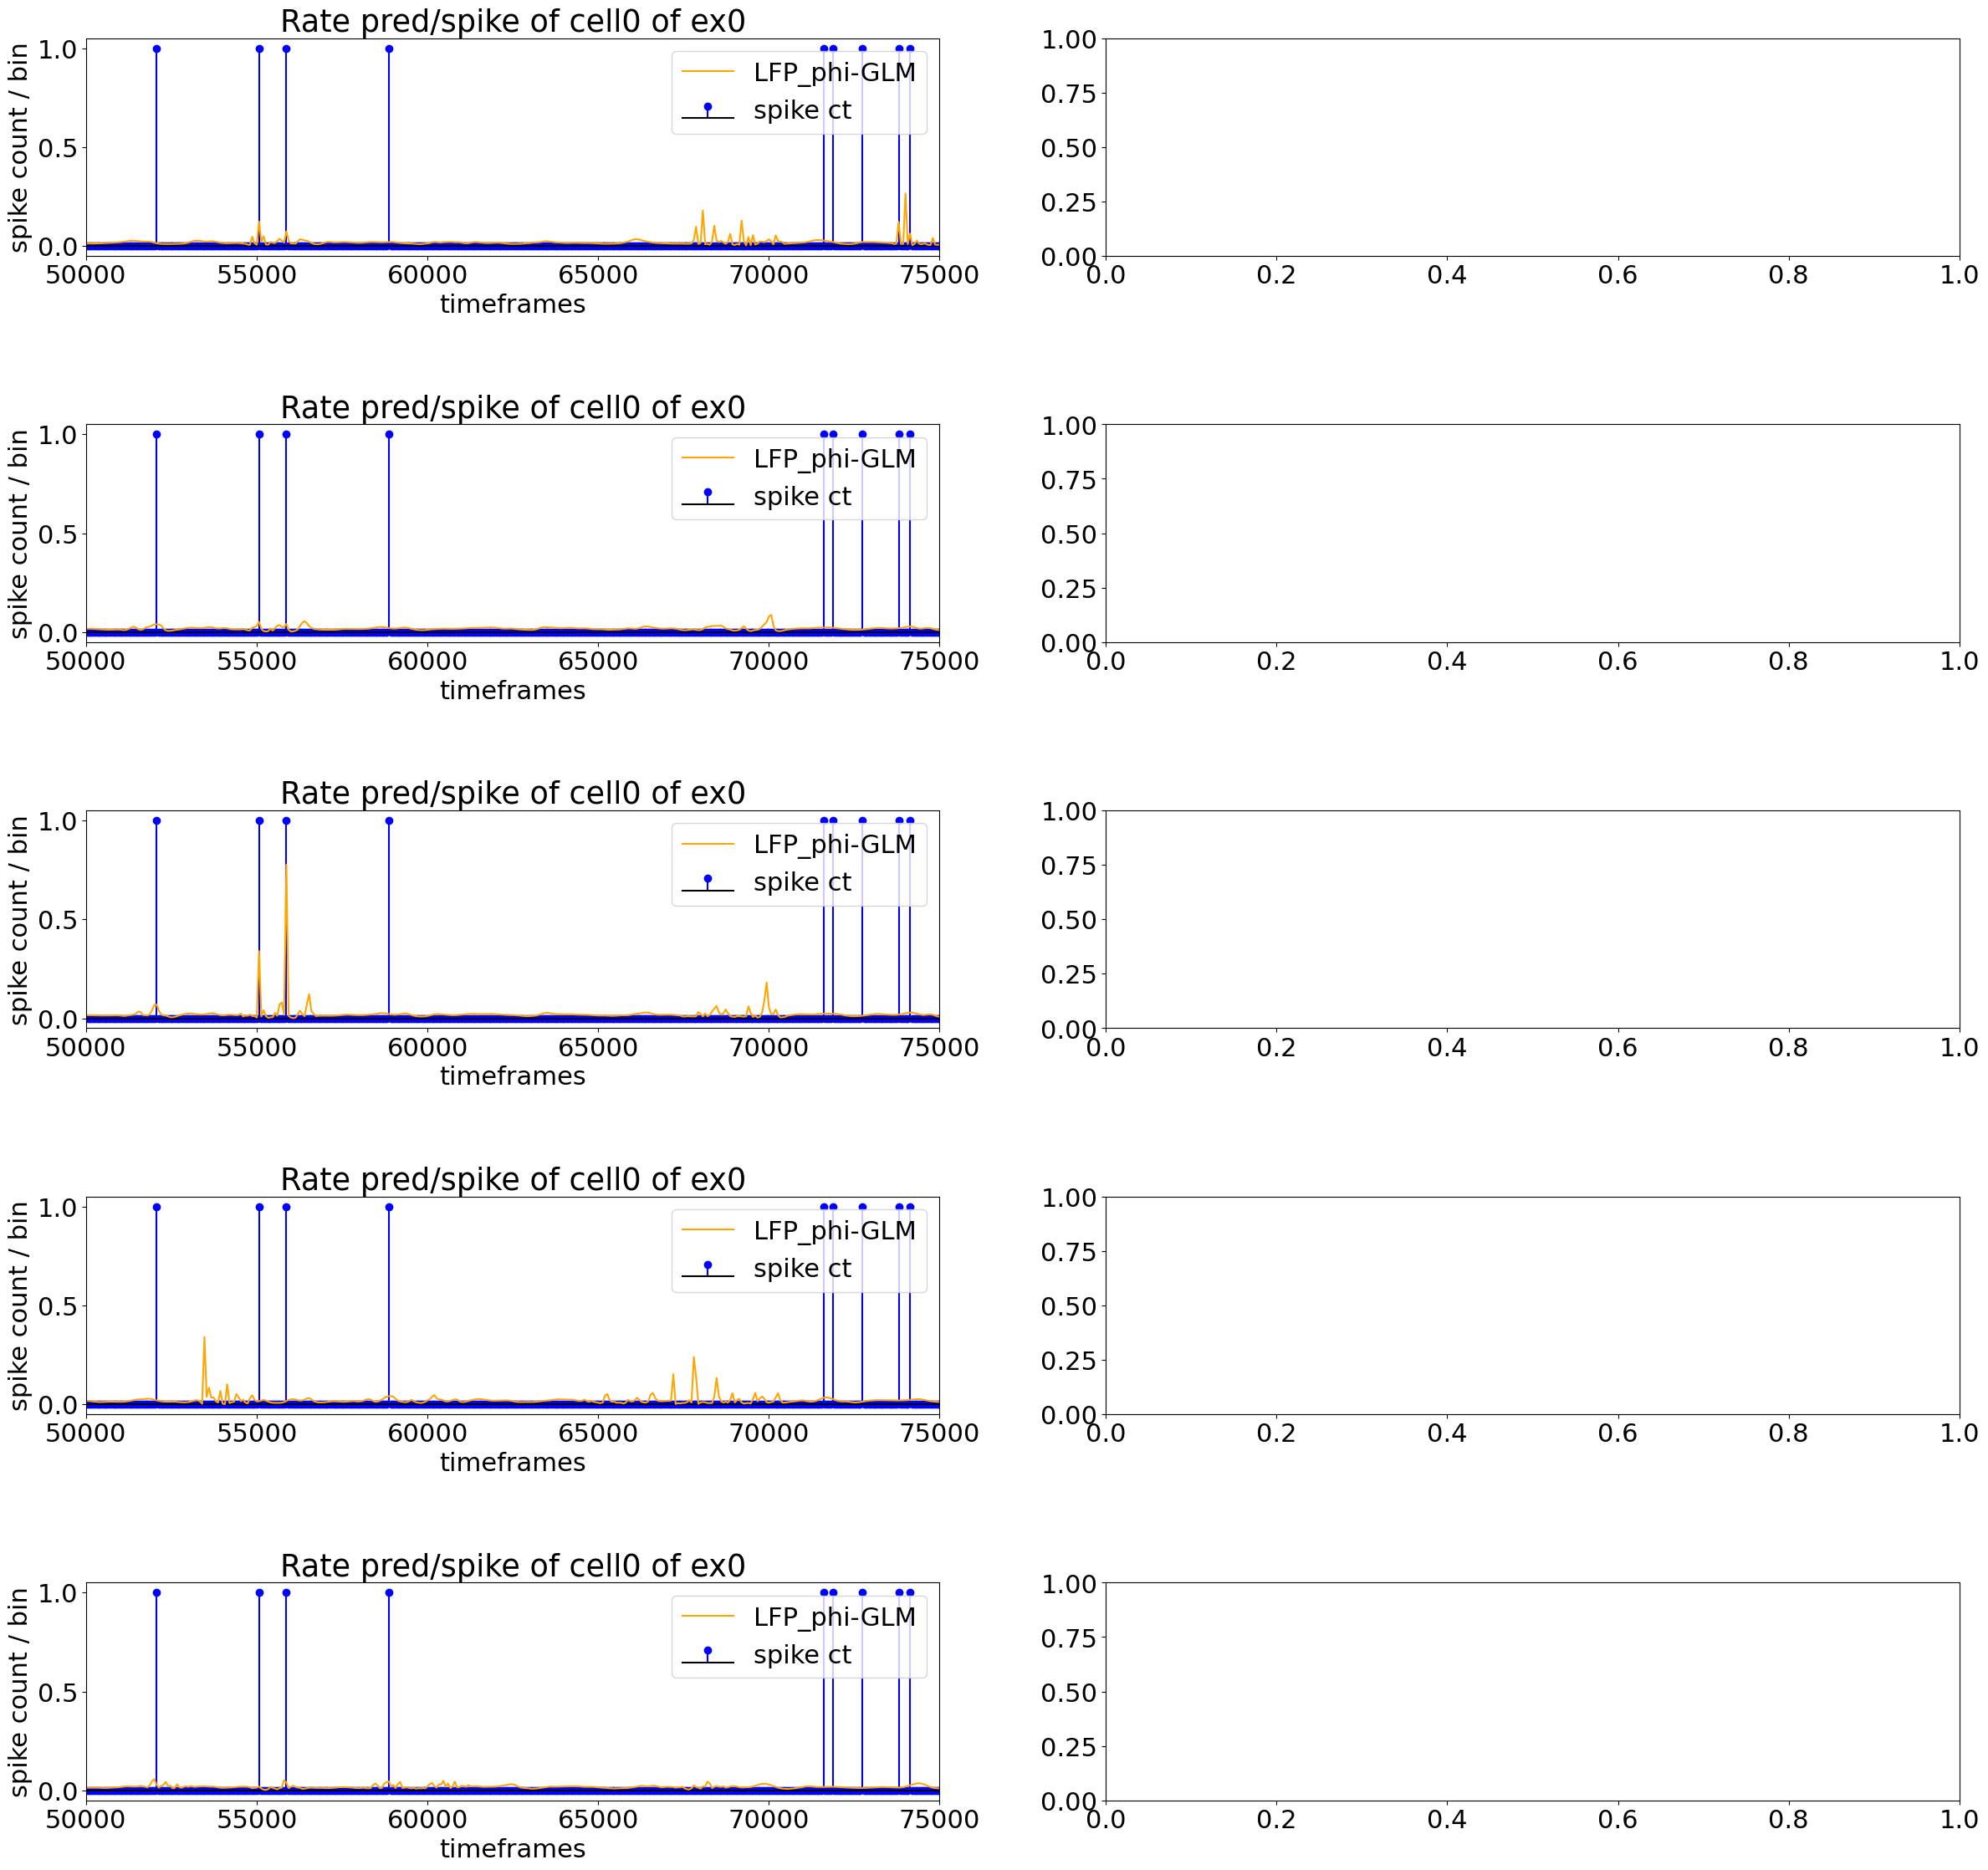

In [19]:
from scipy import stats

dt_lfp = lfp_times_int[1]-lfp_times_int[0] # size of frame
iiplot = np.arange(len(lfp_times_int))
ttplot = iiplot*dt_lfp

plt.clf()
fig, ax = plt.subplots(num_trials, 1, squeeze=False)
fig.set_figheight(4.8*num_trials)
fig.set_figwidth(12.8*2)

for k in np.arange(num_trials):
    phi_int_reshaped = phi_int[k,:]
    phi_int_reshaped = np.reshape(phi_int_reshaped, -1)
    # print(phi_int_reshaped.shape)
    
    X = np.transpose([np.ones(np.shape(phi_int_reshaped)), np.cos(phi_int_reshaped), np.sin(phi_int_reshaped)])
    Y = np.transpose([spikes_binned])
    pGLMphi_model = sm.GLM(Y,X,family=sm.families.Poisson())    # Build the GLM model,
    pGLMphi_results   = pGLMphi_model.fit(max_iter=100, tol=1e-6, tol_criterion='params') 
    phi_predict = np.linspace(-np.pi, np.pi, 100) # x-axis, for plotting
    X_predict = np.transpose([np.ones(np.shape(phi_predict)), np.cos(phi_predict), np.sin(phi_predict)])
    Y_predict = pGLMphi_results.get_prediction(X_predict, linear='False')

    indices = np.argsort(phi_int_reshaped)
    FTA = spikes_binned[indices]
    ax[k][0].plot(np.linspace(-np.pi,np.pi,num_time_bins_int),FTA, label="FTA spikes")
    ax[k][0].plot(phi_predict, Y_predict.predicted_mean, 'k', label="pred")
    ax[k][0].plot(phi_predict, Y_predict.conf_int(), 'k:', label="pred confidence")
    ax[k][0].set_ylim([0, 0.2])
    ax[k][0].set_xlabel("Phase")
    ax[k][0].set_ylabel("Spike probability")


    ## p-value of parameters
    pval1 = pGLMphi_results.pvalues[1]; # significance of parameter beta_1
    pval2 = pGLMphi_results.pvalues[2]; # significance of parameter beta_2
    print(f"[{brain_list[k]}]    p-value of sin: {pval1:.2f}    p-value of cos: {pval2:.2f}")

    ## comparison against model independent of LFP (i.e. B1=0, B2=0)
    X0 = np.ones(np.shape(Y)) # equal to model where beta_1 and beta_2 are set as zero
    null_model = sm.GLM(Y, X0, family=sm.families.Poisson())
    null_res = null_model.fit()
    pval_null = 1-stats.chi2.cdf(null_res.deviance-pGLMphi_results.deviance,2)
    print(f"p-value of null: {pval_null:.2f}") # value is low, so it's unlikely that our big model were to occur if the reduced model was correct
plt.tight_layout(pad=3)

fig, ax = plt.subplots(num_trials, 2, squeeze=False)
fig.set_figheight(4.8*num_trials)
fig.set_figwidth(12.8*2)
# ttk = np.arange(-1*ntfilt+1,1)*dt_lfp_int# time bins for stim filter
ttk = lfp_times_int

ttplot_spike = np.arange(trial_dict["num_time_bins_spike"])*trial_dict["dt_spike"]

for k in np.arange(num_trials):
    phi_int_reshaped = phi_int[k,:]
    phi_int_reshaped = np.reshape(phi_int_reshaped, -1)
    print(phi_int_reshaped.shape)
    phi_stim = np.cos(phi_int_reshaped)
    
    padded_cos = np.hstack((np.zeros(ntfilt-1), phi_stim))
    des_mat_cos = hankel(padded_cos[:-ntfilt+1], phi_stim[-ntfilt:])
    des_mat_cos_offset = np.hstack((np.ones((num_time_bins_int,1)), des_mat_cos))

    '''
    # Build stimulus design matrix (using 'hankel')
    padded_stim = np.hstack((np.zeros(ntfilt-1), stim))   # pad early bins of stimulus with zero
    design_mat_stim = hankel(padded_stim[:-ntfilt+1], stim[-ntfilt:])
    '''
    
    pGLMphi_model = sm.GLM(endog = spikes_binned, exog = des_mat_cos_offset, family=sm.families.Poisson())    # Build the GLM model,
    pGLMphi_results   = pGLMphi_model.fit(max_iter=100, tol=1e-6, tol_criterion='params') 
    pGLMphi_const = pGLMphi_results.params[0]
    pGLMphi_filt = pGLMphi_results.params[1:ntfilt+1]
    rate_pred_phi = np.exp(pGLMphi_const + des_mat_cos @ pGLMphi_results.params[1:])

    ## plotting rate predictions
    ax[k][0].stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', label="spike ct")
    ax[k][0].plot(ttplot_spike, rate_pred_phi, label="LFP_phi-GLM", c='orange')
    ax[k][0].set_xlim([50000, 75000])
    ax[k][0].set_title(f"Rate pred/spike of cell{neuron_idx} of ex{trial_idx}")
    ax[k][0].set_ylabel('spike count / bin')
    ax[k][0].set_xlabel('timeframes')
    ax[k][0].legend(loc='upper right')

plt.tight_layout(pad=3)


# Coupling the Model

Data summary for experimental trial idx0
timefr duration: 200000 at 20,000Hz = 10.0s
timeframes btwn. LFP: 20
timeframes btwn. Spikes: 66.66666666666667
num_time_bins (lfp) = 10000 of size 20.0 timeframes or 0.001 seconds
num_time_bins_spike = 3000 of size 66.66666666666667 timeframes or 0.00333 seconds
number of cells: 7
spike_times shape: (7, 143), type: <class 'numpy.ndarray'>
Spike index (7): [17, 20, 34, 35, 43, 47, 73]
Total spikes over condition duration: [79, 74, 142, 124, 95, 127, 96]
Average firing rate per neuron
['7.90', '7.40', '14.20', '12.40', '9.50', '12.70', '9.60']


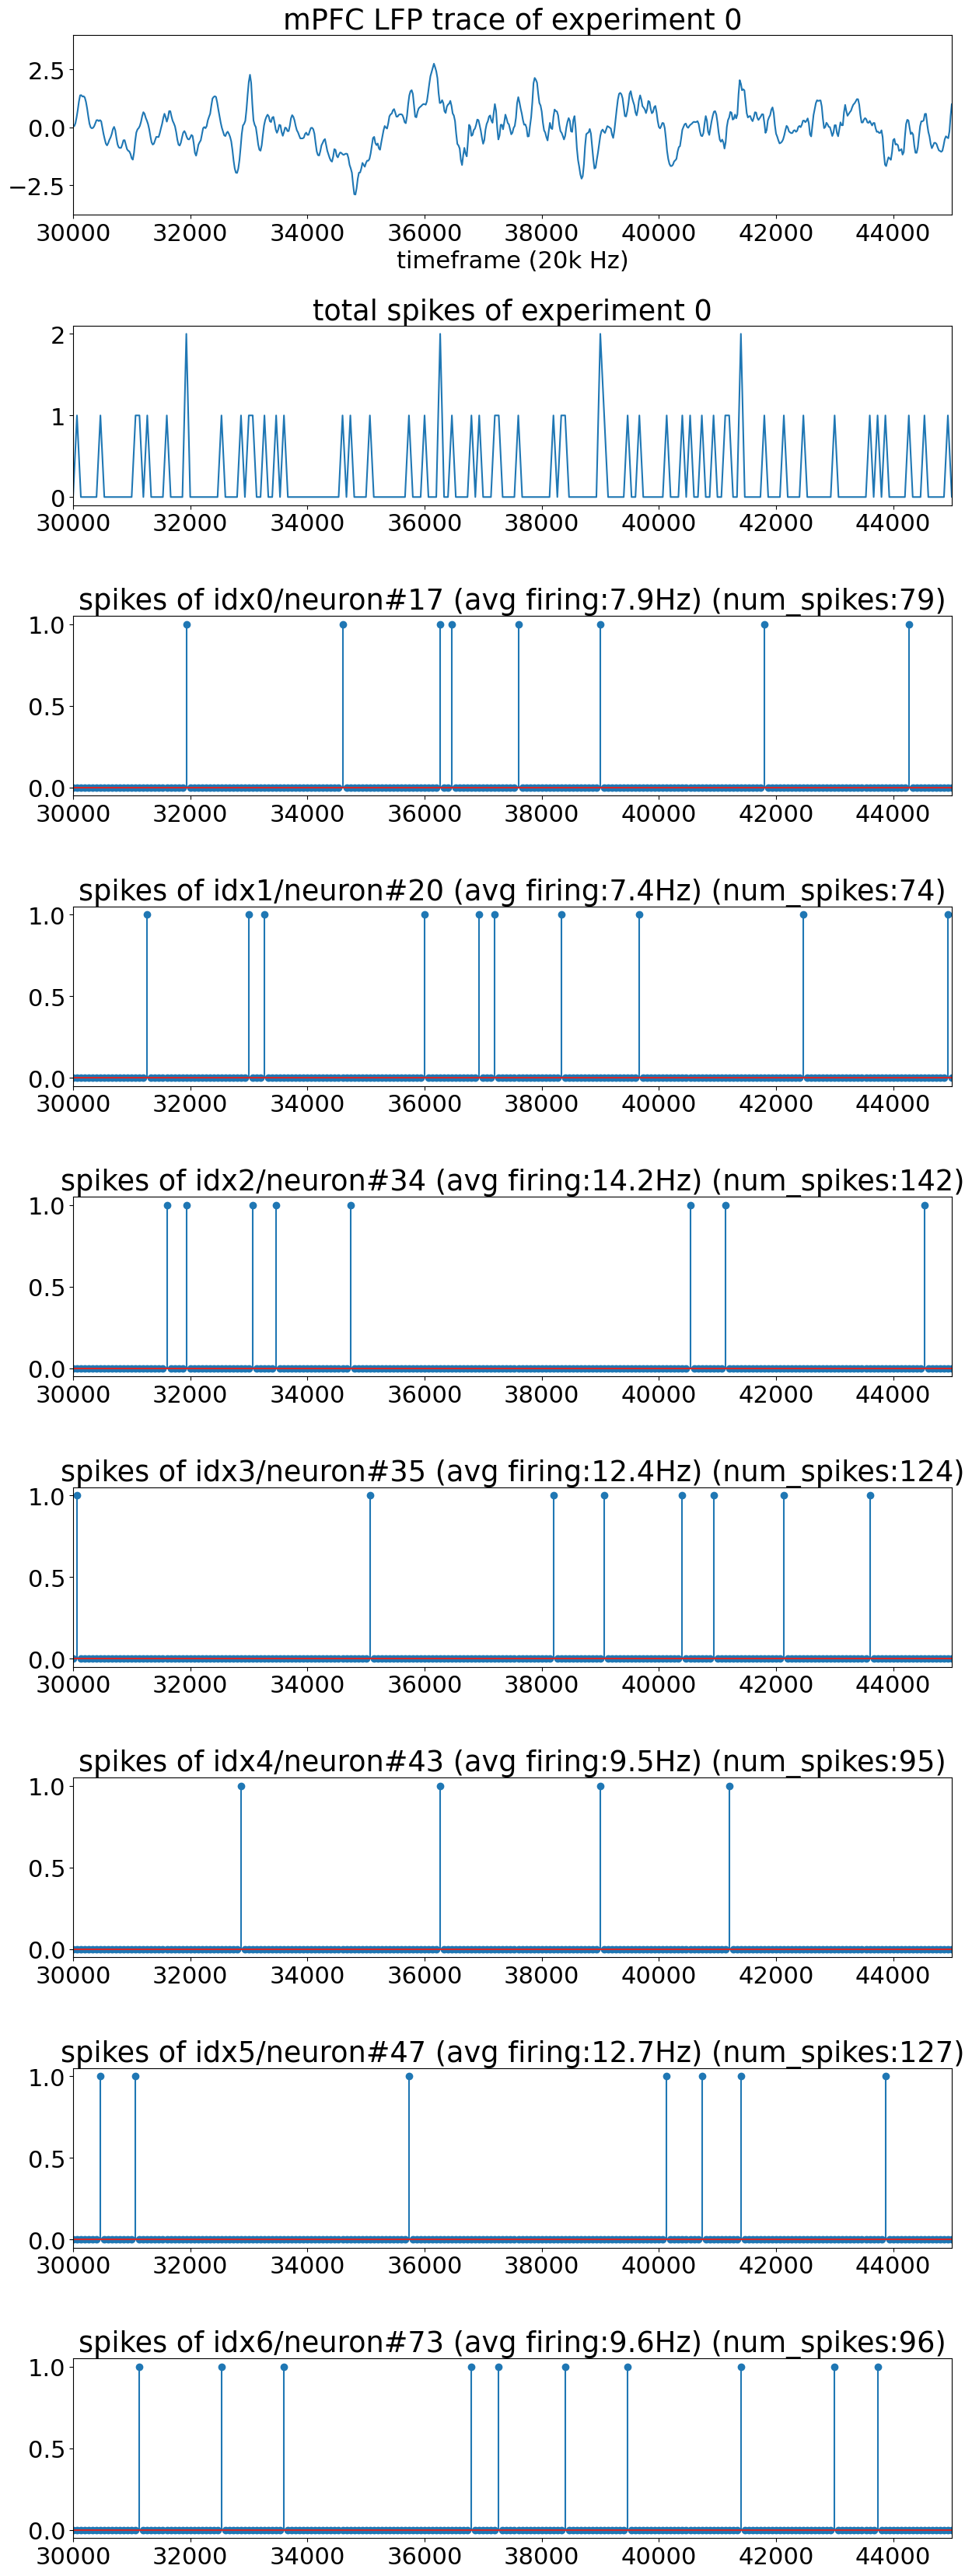

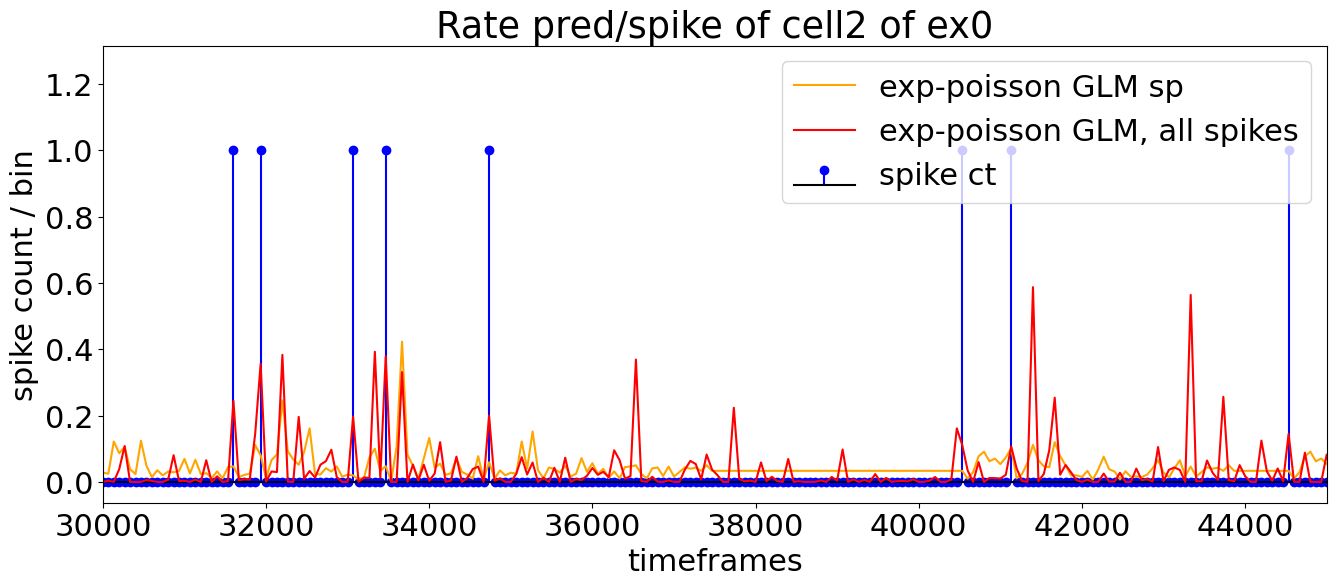

In [20]:
## attempting to pick one with good amount of spikes
# dataframe_DesMatPlot(exp_id=0, cell_idx=2, dataframe = df_sess_train, show_input = True, inplot_xlim = [20000, 80000])
dataframe_DesMatPlot(exp_id=0, cell_idx=2, dataframe = df_sess_train, show_input = True, inplot_xlim = [30000, 45000])
df_sess_test.loc[:,["spike_clusters", "trial_label","subject"]].head(20)
plt.tight_layout(pad=3)

The below plot compares the different spiking rate predictions between the spike-history model (first column, all identical), LFP phase (column 2), and combined phase + spike history (column 3)

p-value of spHist:0.41
Model fitting of spike history complete
]n
AIC change (between spike and phase) of mPFC_lfp: 276.8
AIC change (between spike and coupled) of mPFC_lfp: 495.0
Model fitting of mPFC_lfp complete


AIC change (between spike and phase) of MD_lfp: 286.7
AIC change (between spike and coupled) of MD_lfp: 506.0
Model fitting of MD_lfp complete


AIC change (between spike and phase) of LH_lfp: 272.9
AIC change (between spike and coupled) of LH_lfp: 497.0
Model fitting of LH_lfp complete


AIC change (between spike and phase) of BLA_lfp: 266.5
AIC change (between spike and coupled) of BLA_lfp: 498.4
Model fitting of BLA_lfp complete


AIC change (between spike and phase) of vHPC_lfp: 290.6
AIC change (between spike and coupled) of vHPC_lfp: 508.3
Model fitting of vHPC_lfp complete




<Figure size 640x480 with 0 Axes>

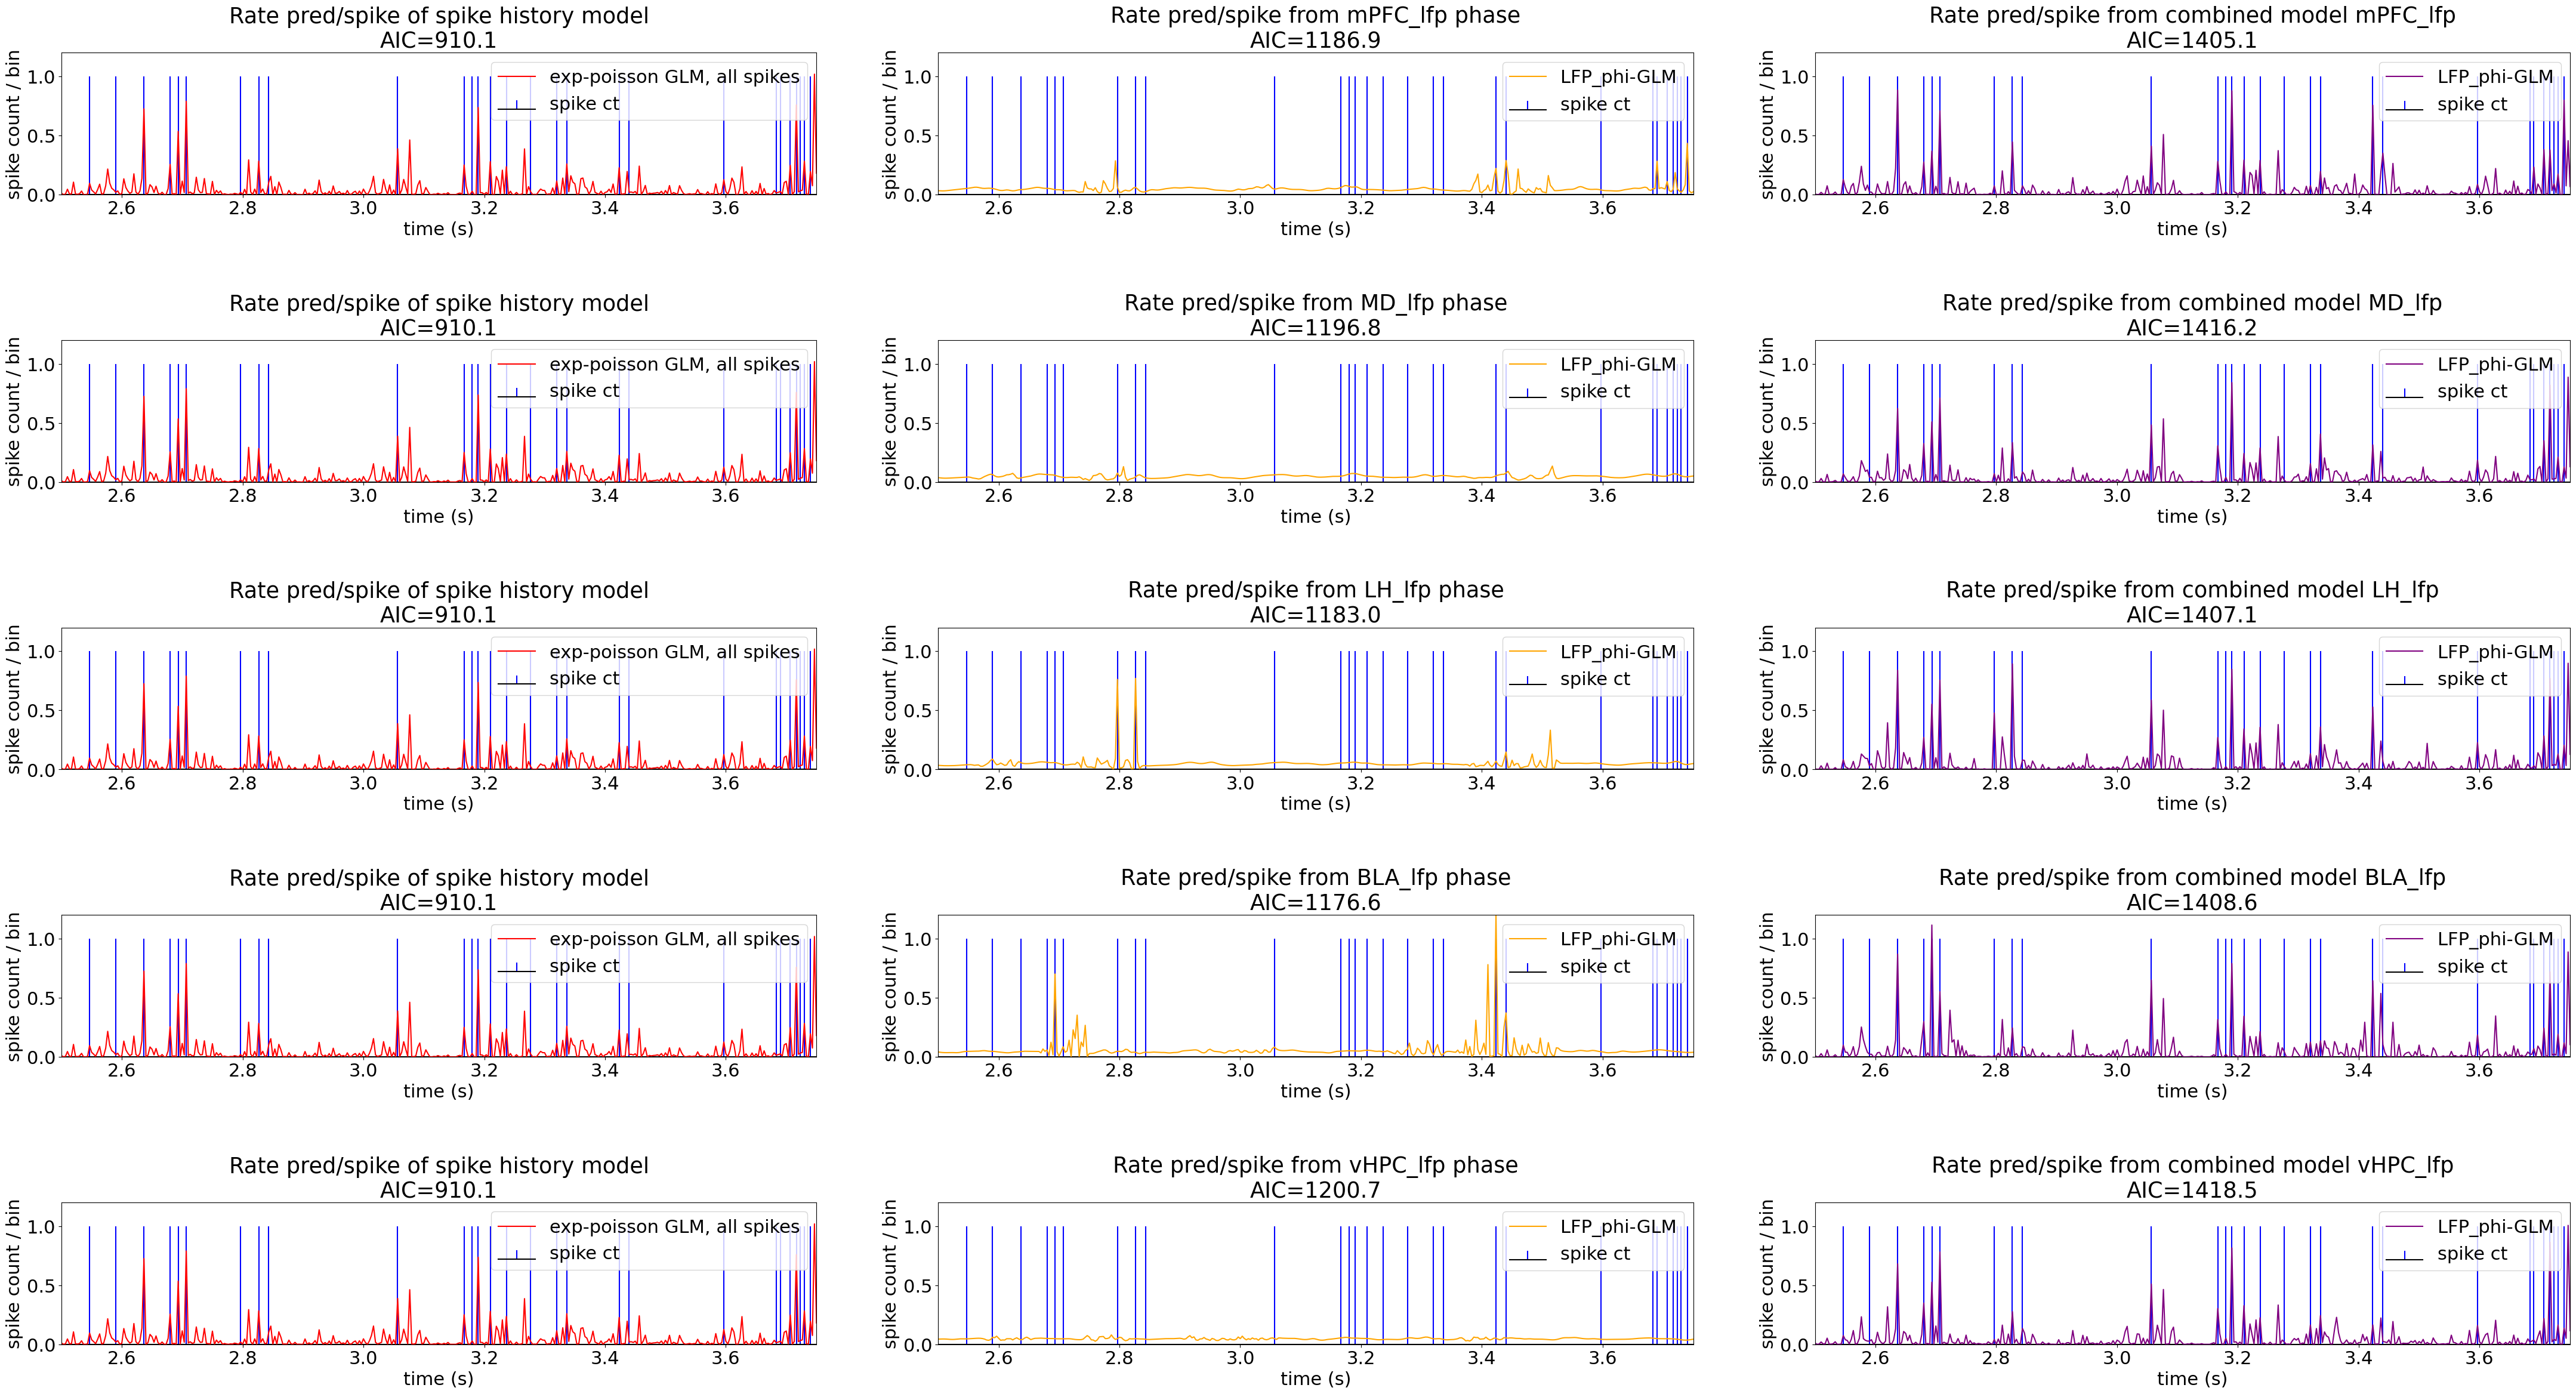

In [23]:
exp_id = 0 # needed for function: not technically needed
cell_idx = 2
ntfilt = 25 # time bins useed in history analysis
nthist = 40
plot_xlim = [2.5, 3.75]
brain_list = ["mPFC_lfp_trace","MD_lfp_trace","LH_lfp_trace","BLA_lfp_trace","vHPC_lfp_trace"]
num_trials = len(brain_list)

trial_dict = dataframe_DesMat(exp_id, cell_idx, dataframe = df_sess_train,
                              min_freq = 0, ntfilt = 50, nthist = 40, print_trial_info = False)
spikes_binned = trial_dict["spikes_binned"] # note: using same spike as ones used in history.
# May not be as "good", but should be fine for presentation

spike_times = trial_dict["spike_times"]
total_spikes_binned = trial_dict["total_spikes_binned"]
design_mat_spikes = trial_dict["design_mat_spikes"]
design_mat_all_spikes = trial_dict["design_mat_all_spikes"]
design_mat_allSp_offset = trial_dict["design_mat_allSpike_offset"]
num_cells = trial_dict["num_cells"]

lfp = trial_dict["lfp"]
lfp_times = trial_dict["lfp_times"]
num_time_bins = trial_dict["num_time_bins"] # no longer used due to interpolation
trial_start_timestamp = df_sess_train["tone_start_timestamp"].iloc[exp_id]
trial_stop_timestamp = trial_start_timestamp + 10*20000

dt_lfp = lfp_times[1]-lfp_times[0] # size of frame
iiplot = np.arange(len(lfp))
ttplot = iiplot*dt_lfp
ttk = lfp_times_int
ttplot_spike = np.arange(trial_dict["num_time_bins_spike"])*trial_dict["dt_spike"] # in timeframes
ttplot_spike = ttplot_spike/20000 # in seconds

'''
Generate LFP phase
'''
fNQ = 2000 
Wn = [30,100] # gamma = [30, 100]
num_time_bins = lfp.size
ord = nthist # filter order, which is Length of filter (num of coefficients, i.e. filter order + 1)
b = signal.firwin(ord, Wn, nyq=fNQ, pass_zero=False, window='hamming');

num_time_bins_int = 3000 
ratio = num_time_bins/num_time_bins_int
lfp_times_int = np.linspace(lfp_times[0],lfp_times[-1],num_time_bins_int)

plt.clf()
fig, ax = plt.subplots(num_trials, 3, squeeze=False)
fig.set_figheight(5*num_trials)
fig.set_figwidth(15*3)

phi = np.zeros([num_trials, num_time_bins])
phi_int = np.zeros([num_trials, num_time_bins_int]) # empty array to hold phase
Vlo_int_all = np.zeros([num_trials, num_time_bins_int])

'''
Spike-model
'''
pGLM_allSp_model = sm.GLM(endog=spikes_binned, exog=design_mat_allSp_offset,
                         family=sm.families.Poisson())
pGLM_allSp_results = pGLM_allSp_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
print(f"p-value of spHist:{pGLM_allSp_results.pvalues[1]:.2f}")
pGLM_allSp_const = pGLM_allSp_results.params[0]
pGLM_allSp_filt = pGLM_allSp_results.params[1:] # pGLM_all_results.params[1:ntfilt+1]
pGLM_allSp_filt = np.reshape(pGLM_allSp_filt, (nthist,num_cells), order='F')
rate_pred_allSp = np.exp(pGLM_allSp_const + design_mat_all_spikes @ pGLM_allSp_results.params[1:])  
print(f"Model fitting of spike history complete")
print("\n")

## calc spike AIC
LL_allSpGLM = spikes_binned.T @ np.log(rate_pred_allSp) - np.sum(rate_pred_allSp)
LL_phiGLM = spikes_binned.T @ np.log(rate_pred_phi) - np.sum(rate_pred_phi)
LL_coupGLM = spikes_binned.T @ np.log(rate_pred_all) - np.sum(rate_pred_all)

## calc homogenous spike, for comparison
spikes_bin_sum = np.sum(spikes_binned)
rate_pred_const = spikes_bin_sum/num_time_bins_int  # mean number of spikes / bin
LL0 = spikes_bin_sum * np.log(rate_pred_const) - num_time_bins_int * np.sum(rate_pred_const);

SSinfo_allSpGLM = (LL_allSpGLM - LL0)/spikes_bin_sum/np.log(2);
# print('\n empirical single-spike information:\n ----------------------');
# print(f'hist-GLM: {SSinfo_allSpGLM:.2f} bits/sp')

# AIC0 = -2*LL_phiGLM + 2*(1+ntfilt);
AIC1 = -2*LL_allSpGLM + 2*(1+nthist); # AIC1 = -2*LL_allSpGLM + 2*(1+nthist*num_cells);
# AIC2 = -2*LL_coupGLM + 2*(1+nthist+ntfilt)

for k in np.arange(num_trials):
    ## phase model
    lfp = df_sess_train[brain_list[k]].iloc[exp_id]
    _, lfp = filter_by_timestamp_range(start=trial_start_timestamp, 
                                       stop=trial_stop_timestamp, timestamps=lfp_times, items=lfp)
    
    Vlo = signal.filtfilt(b, 1, lfp)
    phi[k,:] = np.angle(signal.hilbert(Vlo))
    # ax[k][0].plot(lfp_times,Vlo,'g',label=f"filtered {brain_list[k]} lfp over {Wn}",linewidth=3)
    
    Vlo_intfunc = interp1d(lfp_times, Vlo, kind='cubic')
    Vlo_int = Vlo_intfunc(lfp_times_int)
    Vlo_int_all[k,:] = Vlo_int
    phi_int[k,:] = np.angle(signal.hilbert(Vlo_int)) # compute phase
    
    phi_int_reshaped = phi_int[k,:]
    phi_int_reshaped = np.reshape(phi_int_reshaped, -1)
    phi_stim = np.cos(phi_int_reshaped)
    
    padded_cos = np.hstack((np.zeros(ntfilt-1), phi_stim))
    des_mat_cos = hankel(padded_cos[:-ntfilt+1], phi_stim[-ntfilt:])
    des_mat_cos_offset = np.hstack((np.ones((num_time_bins_int,1)), des_mat_cos))
    
    pGLM_phi_model = sm.GLM(endog = spikes_binned, exog = des_mat_cos_offset, family=sm.families.Poisson())
    pGLM_phi_results   = pGLM_phi_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    pGLM_phi_const = pGLM_phi_results.params[0]
    pGLM_phi_filt = pGLM_phi_results.params[1:ntfilt+1]
    rate_pred_phi = np.exp(pGLM_phi_const + des_mat_cos @ pGLM_phi_results.params[1:])

    '''
    combined model
    '''
    des_mat_all = np.concatenate((des_mat_cos, design_mat_all_spikes), axis=1)
    des_mat_all_offset = np.hstack((np.ones((num_time_bins_int,1)), des_mat_all))
    pGLM_coup_model = sm.GLM(endog=spikes_binned, exog=des_mat_all_offset,
                         family=sm.families.Poisson()) # assumes 'log' link.
    pGLM_coup_results = pGLM_coup_model.fit(max_iter=100, tol=1e-6, tol_criterion='params')
    pGLM_coup_const = pGLM_coup_results.params[0]
    rate_pred_all = np.exp(pGLM_coup_const + des_mat_all @ pGLM_coup_results.params[1:])

    '''
    AIC
    '''
    # SSinfo_phiGLM = (LL_phiGLM - LL0)/spikes_bin_sum/np.log(2);
    # SSinfo_coupGLM = (LL_coupGLM - LL0)/spikes_bin_sum/np.log(2);
    # print(f'phi-GLM: {SSinfo_phiGLM:.2f} bits/sp')
    # print(f'coupled-GLM: {SSinfo_coupGLM:.2f} bits/sp')
    
    LL_phiGLM = spikes_binned.T @ np.log(rate_pred_phi) - np.sum(rate_pred_phi)
    LL_coupGLM = spikes_binned.T @ np.log(rate_pred_all) - np.sum(rate_pred_all)

    ## AIC
    AIC0 = -2*LL_phiGLM + 2*(1+ntfilt);
    # AIC1 = -2*LL_allSpGLM + 2*(1+nthist*num_cells)
    AIC2 = -2*LL_coupGLM + 2*(1+nthist*num_cells+ntfilt)
    AIC_min = np.amin([AIC0, AIC1, AIC2])
    
    # print(f'\n AIC comparison of {brain_list[k].replace("_trace","")}:\n ----------------------')
    # print(f'phi-GLM: {AIC0-AIC_min:.1f}')
    # print(f'Sphist-GLM: {AIC1-AIC_min:.1f}')
    # print(f'coupled-GLM: {AIC2-AIC_min:.1f}')
    # print('\n')
    print(f"AIC change (between spike and phase) of {brain_list[k].replace("_trace","")}: {AIC0-AIC1:.1f}")
    print(f"AIC change (between spike and coupled) of {brain_list[k].replace("_trace","")}: {AIC2-AIC1:.1f}")

    '''
    plots
    '''
    # plotting spike model
    ax[k][0].stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', markerfmt=" ", label="spike ct")
    ax[k][0].plot(ttplot_spike, rate_pred_allSp, label=f"exp-poisson GLM, all spikes", c='red')
    ax[k][0].set_xlim(plot_xlim)
    ax[k][0].set_ylim([0, 1.2])
    ax[k][0].set_title(f"Rate pred/spike of spike history model\nAIC={AIC1:.1f}")
    ax[k][0].set_ylabel('spike count / bin')
    ax[k][0].set_xlabel('time (s)')
    ax[k][0].legend(loc='upper right')
    
    ## plotting rate predictions
    ax[k][1].stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', markerfmt=" ", label="spike ct")
    ax[k][1].plot(ttplot_spike, rate_pred_phi, label="LFP_phi-GLM", c='orange')
    ax[k][1].set_xlim(plot_xlim)
    ax[k][1].set_ylim([0, 1.2])
    # ax[k][1].set_title(f"Rate pred/spike from {brain_list[k].replace("_trace","")} phase\nAIC improvement: {AIC2-AIC1:.1f}")
    ax[k][1].set_title(f"Rate pred/spike from {brain_list[k].replace("_trace","")} phase\nAIC={AIC0:.1f}")
    ax[k][1].set_ylabel('spike count / bin')
    ax[k][1].set_xlabel('time (s)')
    ax[k][1].legend(loc='upper right')
    
    ax[k][2].stem(ttplot_spike, spikes_binned, linefmt='b-', basefmt='k-', markerfmt=" ",label="spike ct")
    ax[k][2].plot(ttplot_spike, rate_pred_all, label="LFP_phi-GLM", c='purple')
    ax[k][2].set_xlim(plot_xlim)
    ax[k][2].set_ylim([0, 1.2])
    # ax[k][2].set_title(f"Rate pred/spike from combined model {brain_list[k].replace("_trace","")}]nAIC improvement:{AIC2-AIC1:.1f}")
    ax[k][2].set_title(f"Rate pred/spike from combined model {brain_list[k].replace("_trace","")}\nAIC={AIC2:.1f}")
    ax[k][2].set_ylabel('spike count / bin')
    ax[k][2].set_xlabel('time (s)')
    ax[k][2].legend(loc='upper right')
    print(f"Model fitting of {brain_list[k].replace("_trace","")} complete")
    print("\n")

    # plt.plot(pGLM_coup_results.pvalues)

plt.tight_layout(pad=3)

In [22]:

'''
mPFC = 1405.1
MD = 1416.2

LH = 1407.1
BLA = 1408.6
vHPC = 1418.5

hist = 910.1

def per_inc(brain):
    print((brain-hist)/hist)
    return


temp = pGLM_coup_results.pvalues
# print(np.around(temp, 3))
print(len(temp))
print(nthist)
print(ntfilt)
print(num_cells)

print(design_mat_all_spikes.shape)
print(des_mat_cos.shape)
print(des_mat_all.shape)

'''

306
40
25
7
(3000, 280)
(3000, 25)
(3000, 305)
